# 7CUSMNDA-Network-Data-Analysis
created by Hsiang-Yin 04/08/2026

In [15]:
from shapely.geometry import Point, box
import osmnx as ox
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path
from shapely.geometry import Point, LineString, MultiLineString
from shapely.ops import linemerge, unary_union
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import shortest_path
import random
import math
from shapely.geometry import box
from itertools import combinations
import spaghetti
from libpysal.weights import W
from splot.esda import moran_scatterplot, plot_moran




In [16]:

# -------------------------
# 1. User settings
# -------------------------

DATA_DIR = Path("./data")   # 改成你的資料夾路徑，例如 Path("/content/data")
FILES = {
    2012: DATA_DIR / "2012.csv",
    2013: DATA_DIR / "2013.csv",
    2014: DATA_DIR / "2014.csv",
    2015: DATA_DIR / "2015.csv",
    2016: DATA_DIR / "2016.csv",
}

# British National Grid
CRS_BNG = "EPSG:27700"
CRS_WGS84 = "EPSG:4326"

# Leeds city centre 附近的大搜尋框（可再微調）
# 單位：metres in EPSG:27700
CENTRE_SEARCH_BOUNDS = (428000, 432000, 432000, 436000)
# xmin, ymin, xmax, ymax  -> 4 km x 4 km

WINDOW_SIZE = 1000   # 1 km x 1 km
STEP = 100           # 滑動步長，100m
TOP_N = 10           # 顯示前幾名候選區


# -------------------------
# 2. Load and harmonise files
# -------------------------

def load_accident_file(path, year):
    """
    Load one annual CSV and standardise key columns.
    Handles slight schema differences across years.
    """
    df = pd.read_csv(path, encoding="latin1")

    rename_map = {
        "Reference Number": "reference_number",
        "Accident Date": "accident_date",
        "Date": "accident_date",
        "Easting": "easting",
        "Northing": "northing",
        "Grid Ref: Easting": "easting",
        "Grid Ref: Northing": "northing",
    }
    df = df.rename(columns=rename_map)

    required_cols = ["reference_number", "easting", "northing"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{path.name} 缺少必要欄位: {missing}")

    keep_cols = [c for c in ["reference_number", "easting", "northing", "accident_date"] if c in df.columns]
    df = df[keep_cols].copy()
    df["year"] = year

    # Numeric conversion
    df["easting"] = pd.to_numeric(df["easting"], errors="coerce")
    df["northing"] = pd.to_numeric(df["northing"], errors="coerce")

    # Drop missing coordinate or reference values
    df = df.dropna(subset=["reference_number", "easting", "northing"]).copy()

    # Strip whitespace
    df["reference_number"] = df["reference_number"].astype(str).str.strip()

    return df


def load_all_years(files_dict):
    dfs = []
    for year, path in files_dict.items():
        print(f"Loading {path.name} ...")
        df = load_accident_file(path, year)
        df["source_file"] = path.name
        dfs.append(df)

    combined = pd.concat(dfs, ignore_index=True)
    return combined


# -------------------------
# 3. Convert casualty-level -> accident-level
# -------------------------

def deduplicate_to_accident_level(df):
    """
    Keep one row per unique accident reference.
    Since the dataset is casualty-level, multiple rows may belong to the same accident.
    """
    accidents = (
        df.sort_values(["reference_number", "year"])
          .drop_duplicates(subset=["reference_number"])
          .reset_index(drop=True)
    )
    return accidents


# -------------------------
# 4. Build GeoDataFrame
# -------------------------

def build_geodataframe(df, crs=CRS_BNG):
    gdf = gpd.GeoDataFrame(
        df.copy(),
        geometry=gpd.points_from_xy(df["easting"], df["northing"]),
        crs=crs
    )
    return gdf


# -------------------------
# 5. Restrict to Leeds centre search area
# -------------------------

def filter_to_search_area(gdf, bounds):
    xmin, ymin, xmax, ymax = bounds
    search_poly = box(xmin, ymin, xmax, ymax)
    filtered = gdf[gdf.within(search_poly)].copy()
    search_gdf = gpd.GeoDataFrame(
        {"name": ["centre_search_area"]},
        geometry=[search_poly],
        crs=gdf.crs
    )
    return filtered, search_gdf


# -------------------------
# 6. Generate 1 km² candidate windows
# -------------------------

def count_accidents_in_windows(gdf_points, search_bounds, window_size=1000, step=100):
    """
    Slide a square window across the search area and count accidents inside each window.
    """
    xmin, ymin, xmax, ymax = search_bounds
    results = []

    xs = np.arange(xmin, xmax - window_size + step, step)
    ys = np.arange(ymin, ymax - window_size + step, step)

    total_windows = len(xs) * len(ys)
    print(f"Evaluating {total_windows} candidate windows ...")

    for x in xs:
        for y in ys:
            candidate_poly = box(x, y, x + window_size, y + window_size)

            count = gdf_points.within(candidate_poly).sum()

            results.append({
                "xmin": x,
                "ymin": y,
                "xmax": x + window_size,
                "ymax": y + window_size,
                "accident_count": int(count),
                "geometry": candidate_poly
            })

    candidates = gpd.GeoDataFrame(results, geometry="geometry", crs=gdf_points.crs)
    candidates = candidates.sort_values("accident_count", ascending=False).reset_index(drop=True)
    candidates["rank"] = np.arange(1, len(candidates) + 1)
    return candidates


# -------------------------
# 7. Convert bounds to lat/lon for OSMnx later
# -------------------------

def bounds_to_latlon(bounds, source_crs=CRS_BNG):
    xmin, ymin, xmax, ymax = bounds
    corners = gpd.GeoDataFrame(
        geometry=[Point(xmin, ymin), Point(xmax, ymax)],
        crs=source_crs
    ).to_crs(CRS_WGS84)

    min_lon, min_lat = corners.geometry.iloc[0].x, corners.geometry.iloc[0].y
    max_lon, max_lat = corners.geometry.iloc[1].x, corners.geometry.iloc[1].y

    return {
        "west": min_lon,
        "south": min_lat,
        "east": max_lon,
        "north": max_lat
    }


# -------------------------
# 8. Plot results
# -------------------------

def plot_top_candidates(gdf_points, search_area_gdf, candidate_boxes, top_n=10, figsize=(10, 10)):
    top = candidate_boxes.head(top_n).copy()

    fig, ax = plt.subplots(figsize=figsize)

    search_area_gdf.boundary.plot(ax=ax, linewidth=2, linestyle="--")
    gdf_points.plot(ax=ax, markersize=4, alpha=0.35)
    top.boundary.plot(ax=ax, linewidth=2)

    # 標註前幾名框的 rank
    for _, row in top.iterrows():
        centroid = row.geometry.centroid
        ax.text(centroid.x, centroid.y, str(int(row["rank"])), fontsize=10)

    ax.set_title(f"Top {top_n} candidate 1 km² study areas in central Leeds")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    plt.tight_layout()
    plt.show()


def plot_final_area(gdf_points, final_box_gdf, figsize=(8, 8)):
    fig, ax = plt.subplots(figsize=figsize)
    gdf_points.plot(ax=ax, markersize=5, alpha=0.35)
    final_box_gdf.boundary.plot(ax=ax, linewidth=3)
    ax.set_title("Selected final 1 km² study area")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    plt.tight_layout()
    plt.show()


# -------------------------
# 9. Main workflow
# -------------------------

def process_data():
    # Load
    raw_df = load_all_years(FILES)

    print("\n--- Raw combined data ---")
    print(f"Raw rows (casualty-level): {len(raw_df):,}")
    print(f"Unique reference numbers: {raw_df['reference_number'].nunique():,}")

    # Deduplicate to accident-level
    accidents_df = deduplicate_to_accident_level(raw_df)

    print("\n--- Accident-level data ---")
    print(f"Unique accidents: {len(accidents_df):,}")

    # Build GeoDataFrame
    gdf = build_geodataframe(accidents_df, crs=CRS_BNG)

    # Restrict to Leeds centre search area
    gdf_centre, search_area_gdf = filter_to_search_area(gdf, CENTRE_SEARCH_BOUNDS)

    print("\n--- Central Leeds search area ---")
    print(f"Accidents inside central search area: {len(gdf_centre):,}")

    # Generate and rank candidate windows
    candidates = count_accidents_in_windows(
        gdf_points=gdf_centre,
        search_bounds=CENTRE_SEARCH_BOUNDS,
        window_size=WINDOW_SIZE,
        step=STEP
    )

    print("\n--- Top candidate windows ---")
    print(candidates.head(TOP_N)[["rank", "xmin", "ymin", "xmax", "ymax", "accident_count"]])

    # Final selected box = rank 1
    best = candidates.iloc[0]
    final_bounds = (best["xmin"], best["ymin"], best["xmax"], best["ymax"])
    final_box_gdf = gpd.GeoDataFrame(
        {"name": ["final_study_area"], "accident_count": [best["accident_count"]]},
        geometry=[best.geometry],
        crs=CRS_BNG
    )

    print("\n--- Final selected study area ---")
    print(f"Bounding box (EPSG:27700): {final_bounds}")
    print(f"5-year accident count: {best['accident_count']}")

    latlon_bounds = bounds_to_latlon(final_bounds)
    print("\nBounding box for OSMnx / lat-lon:")
    print(latlon_bounds)

    # Plots
    plot_top_candidates(gdf_centre, search_area_gdf, candidates, top_n=TOP_N)
    plot_final_area(gdf_centre, final_box_gdf)

    # Save outputs
    candidates_out = candidates.drop(columns="geometry").copy()
    candidates_out.to_csv("candidate_windows_ranked.csv", index=False)

    final_summary = pd.DataFrame([{
        "xmin": best["xmin"],
        "ymin": best["ymin"],
        "xmax": best["xmax"],
        "ymax": best["ymax"],
        "accident_count": best["accident_count"],
        "west": latlon_bounds["west"],
        "south": latlon_bounds["south"],
        "east": latlon_bounds["east"],
        "north": latlon_bounds["north"],
    }])
    final_summary.to_csv("final_study_area_summary.csv", index=False)

    print("\n已輸出：")
    print("- candidate_windows_ranked.csv")
    print("- final_study_area_summary.csv")

    return {
        "raw_df": raw_df,
        "accidents_df": accidents_df,
        "gdf": gdf,
        "gdf_centre": gdf_centre,
        "candidates": candidates,
        "final_box_gdf": final_box_gdf,
        "final_bounds_epsg27700": final_bounds,
        "final_bounds_latlon": latlon_bounds
    }

In [17]:
# =========================
# Part 2 - Task A
# OSMnx road network + summary metrics
# =========================

# OSMnx settings
ox.settings.use_cache = True
ox.settings.log_console = True

CRS_BNG = "EPSG:27700"
CRS_WGS84 = "EPSG:4326"


# -------------------------
# 1. Build study area polygon from previous step
# -------------------------

def get_study_area_from_results(results):
    """
    Use the final bounding box chosen earlier and convert it to a polygon.
    """
    xmin, ymin, xmax, ymax = results["final_bounds_epsg27700"]
    study_poly_bng = box(xmin, ymin, xmax, ymax)

    study_area_bng = gpd.GeoDataFrame(
        {"name": ["study_area"]},
        geometry=[study_poly_bng],
        crs=CRS_BNG
    )

    study_area_wgs84 = study_area_bng.to_crs(CRS_WGS84)
    return study_area_bng, study_area_wgs84


# -------------------------
# 2. Download OSM driving road network
# -------------------------

def download_drive_network(study_area_wgs84):
    """
    Download driving network from OSM using the selected 1 km² study polygon.
    """
    polygon = study_area_wgs84.geometry.iloc[0]

    G = ox.graph_from_polygon(
        polygon,
        network_type="drive",
        simplify=True
    )
    return G


# -------------------------
# 3. Project graph and convert to GeoDataFrames
# -------------------------

def project_graph_to_bng(G):
    """
    Project graph to British National Grid for metric calculations.
    """
    G_proj = ox.project_graph(G, to_crs=CRS_BNG)
    nodes, edges = ox.graph_to_gdfs(G_proj, nodes=True, edges=True)
    return G_proj, nodes, edges


# -------------------------
# 4. Helper functions for network summary metrics
# -------------------------

def get_largest_undirected_component(G):
    """
    Use largest connected component of the undirected version for distance-based metrics.
    """
    G_u = ox.convert.to_undirected(G)
    largest_cc_nodes = max(nx.connected_components(G_u), key=len)
    G_lcc = G_u.subgraph(largest_cc_nodes).copy()
    return G_lcc


def intersection_nodes(nodes_gdf):
    """
    Approximate intersections as nodes with degree >= 3 in the undirected graph context.
    This is a practical approximation for reporting intersection density.
    """
    # degree 欄位稍後由 graph 補進去較準
    return nodes_gdf[nodes_gdf["street_count"].fillna(0) >= 3].copy()


def safe_mean(series):
    return float(series.mean()) if len(series) > 0 else np.nan


# -------------------------
# 5. Compute summary metrics required for Task A
# -------------------------

def compute_task_a_metrics(G_proj, nodes, edges, study_area_bng):
    """
    Compute:
    - spatial diameter
    - average street length
    - node density
    - intersection density
    - edge density
    plus extra useful descriptors
    """
    area_m2 = study_area_bng.geometry.iloc[0].area
    area_km2 = area_m2 / 1_000_000

    # Largest connected component for distance-based metric
    G_lcc = get_largest_undirected_component(G_proj)

    # Spatial diameter = maximum shortest path length by metres
    spatial_diameter_m = nx.diameter(G_lcc, weight="length")

    # Average street length
    avg_street_length_m = safe_mean(edges["length"])

    # Node density
    node_density_per_km2 = len(nodes) / area_km2

    # Intersection density
    intersections = intersection_nodes(nodes)
    intersection_density_per_km2 = len(intersections) / area_km2

    # Edge density (total edge length per km²)
    total_edge_length_m = edges["length"].sum()
    edge_density_m_per_km2 = total_edge_length_m / area_km2

    # Extra useful stats
    total_nodes = len(nodes)
    total_edges = len(edges)
    total_street_length_km = total_edge_length_m / 1000

    metrics = {
        "area_km2": area_km2,
        "total_nodes": total_nodes,
        "total_edges": total_edges,
        "total_intersections": len(intersections),
        "total_edge_length_m": total_edge_length_m,
        "total_edge_length_km": total_street_length_km,
        "spatial_diameter_m": spatial_diameter_m,
        "avg_street_length_m": avg_street_length_m,
        "node_density_per_km2": node_density_per_km2,
        "intersection_density_per_km2": intersection_density_per_km2,
        "edge_density_m_per_km2": edge_density_m_per_km2,
    }

    return metrics, intersections, G_lcc


# -------------------------
# 6. Average circuitry
# -------------------------

def compute_average_circuitry(G_proj, nodes, sample_size=300, random_state=42):
    """
    Average circuitry = network distance / Euclidean distance for node pairs.
    Uses a random sample of nodes for efficiency.

    The graph is converted to the largest undirected connected component.
    """
    rng = np.random.default_rng(random_state)

    G_lcc = get_largest_undirected_component(G_proj)
    lcc_nodes = list(G_lcc.nodes)

    if len(lcc_nodes) < 2:
        return np.nan, None

    # sample nodes if graph is large
    if len(lcc_nodes) > sample_size:
        sampled_nodes = rng.choice(lcc_nodes, size=sample_size, replace=False)
        sampled_nodes = list(sampled_nodes)
    else:
        sampled_nodes = lcc_nodes

    # node coordinate lookup
    node_xy = {}
    for n, data in G_lcc.nodes(data=True):
        node_xy[n] = (data["x"], data["y"])

    ratios = []

    # compute pairwise ratios on sampled nodes
    for u, v in combinations(sampled_nodes, 2):
        x1, y1 = node_xy[u]
        x2, y2 = node_xy[v]

        euclidean = np.hypot(x2 - x1, y2 - y1)
        if euclidean == 0:
            continue

        try:
            network_dist = nx.shortest_path_length(G_lcc, u, v, weight="length")
            ratios.append(network_dist / euclidean)
        except nx.NetworkXNoPath:
            continue

    avg_circuitry = float(np.mean(ratios)) if ratios else np.nan
    return avg_circuitry, ratios


# -------------------------
# 7. Planarity diagnostics
# -------------------------

def planarity_diagnostics(G_proj):
    """
    Basic topological planarity check on the undirected graph.
    Note:
    This checks graph-theoretic planarity, not whether real roads cross by bridges/tunnels.
    """
    G_u = ox.convert.to_undirected(G_proj)
    is_planar, embedding = nx.check_planarity(G_u)

    diag = {
        "topologically_planar": is_planar,
        "n_nodes_undirected": G_u.number_of_nodes(),
        "n_edges_undirected": G_u.number_of_edges(),
    }
    return diag


# -------------------------
# 8. Plot network
# -------------------------

def plot_study_network(edges, study_area_bng, figsize=(10, 10)):
    fig, ax = plt.subplots(figsize=figsize)

    study_area_bng.boundary.plot(ax=ax, linewidth=2, linestyle="--")
    edges.plot(ax=ax, linewidth=1)

    ax.set_title("Driving road network in the selected 1 km² study area")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    plt.tight_layout()
    plt.show()


def plot_network_with_intersections(edges, intersections, study_area_bng, figsize=(10, 10)):
    fig, ax = plt.subplots(figsize=figsize)

    study_area_bng.boundary.plot(ax=ax, linewidth=2, linestyle="--")
    edges.plot(ax=ax, linewidth=1)
    intersections.plot(ax=ax, markersize=20)

    ax.set_title("Driving network and approximated intersections")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    plt.tight_layout()
    plt.show()


# -------------------------
# 9. Export summary tables
# -------------------------

def export_task_a_outputs(metrics, circuitry, planarity_info, study_area_bng, study_area_wgs84):
    xmin, ymin, xmax, ymax = study_area_bng.total_bounds
    west, south, east, north = study_area_wgs84.total_bounds

    summary = {
        "xmin_bng": xmin,
        "ymin_bng": ymin,
        "xmax_bng": xmax,
        "ymax_bng": ymax,
        "west_lon": west,
        "south_lat": south,
        "east_lon": east,
        "north_lat": north,
        **metrics,
        "average_circuitry": circuitry,
        **planarity_info
    }

    summary_df = pd.DataFrame([summary])
    summary_df.to_csv("taskA_summary_metrics.csv", index=False)

    nice_table = pd.DataFrame({
        "Metric": [
            "Study area (km²)",
            "Total nodes",
            "Total edges",
            "Total intersections",
            "Total edge length (km)",
            "Spatial diameter (m)",
            "Average street length (m)",
            "Node density (per km²)",
            "Intersection density (per km²)",
            "Edge density (m per km²)",
            "Average circuitry",
            "Topologically planar?"
        ],
        "Value": [
            round(metrics["area_km2"], 3),
            metrics["total_nodes"],
            metrics["total_edges"],
            metrics["total_intersections"],
            round(metrics["total_edge_length_km"], 3),
            round(metrics["spatial_diameter_m"], 2),
            round(metrics["avg_street_length_m"], 2),
            round(metrics["node_density_per_km2"], 2),
            round(metrics["intersection_density_per_km2"], 2),
            round(metrics["edge_density_m_per_km2"], 2),
            round(circuitry, 4) if pd.notna(circuitry) else np.nan,
            planarity_info["topologically_planar"]
        ]
    })
    nice_table.to_csv("taskA_summary_table.csv", index=False)

    print("\n已輸出：")
    print("- taskA_summary_metrics.csv")
    print("- taskA_summary_table.csv")

    return summary_df, nice_table


# -------------------------
# 10. Main Task A workflow
# -------------------------

def run_task_a(results):
    # Step 1. Study area polygon
    study_area_bng, study_area_wgs84 = get_study_area_from_results(results)

    # Step 2. Download OSM driving network
    G = download_drive_network(study_area_wgs84)

    # Step 3. Project and convert
    G_proj, nodes, edges = project_graph_to_bng(G)

    # Step 4. Summary metrics
    metrics, intersections, G_lcc = compute_task_a_metrics(G_proj, nodes, edges, study_area_bng)

    # Step 5. Average circuitry
    avg_circuitry, circuitry_ratios = compute_average_circuitry(
        G_proj,
        nodes,
        sample_size=300,
        random_state=42
    )

    # Step 6. Planarity diagnostics
    planarity_info = planarity_diagnostics(G_proj)

    # Step 7. Print summary
    print("\n=== Task A summary ===")
    for k, v in metrics.items():
        print(f"{k}: {v}")

    print(f"average_circuitry: {avg_circuitry}")
    print(f"planarity_info: {planarity_info}")

    # Step 8. Plots
    plot_study_network(edges, study_area_bng)
    plot_network_with_intersections(edges, intersections, study_area_bng)

    # Step 9. Export tables
    summary_df, nice_table = export_task_a_outputs(
        metrics,
        avg_circuitry,
        planarity_info,
        study_area_bng,
        study_area_wgs84
    )

    return {
        "study_area_bng": study_area_bng,
        "study_area_wgs84": study_area_wgs84,
        "G": G,
        "G_proj": G_proj,
        "nodes": nodes,
        "edges": edges,
        "intersections": intersections,
        "metrics": metrics,
        "average_circuitry": avg_circuitry,
        "circuitry_ratios": circuitry_ratios,
        "planarity_info": planarity_info,
        "summary_df": summary_df,
        "nice_table": nice_table,
        "G_lcc": G_lcc
    }

# =========================
# Part 2 - Task A formal outputs
# Figures + publication-style table
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from pathlib import Path

OUTPUT_DIR = Path("taskA_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


# -------------------------
# 1. Helper: clean metric labels
# -------------------------

def build_taskA_report_table(taskA):
    metrics = taskA["metrics"]
    circuitry = taskA["average_circuitry"]
    planarity = taskA["planarity_info"]["topologically_planar"]

    report_table = pd.DataFrame({
        "Metric": [
            "Study area (km²)",
            "Total nodes",
            "Total edges",
            "Total intersections",
            "Total edge length (km)",
            "Spatial diameter (m)",
            "Average street length (m)",
            "Node density (per km²)",
            "Intersection density (per km²)",
            "Edge density (m per km²)",
            "Average circuitry",
            "Topologically planar"
        ],
        "Value": [
            round(metrics["area_km2"], 3),
            int(metrics["total_nodes"]),
            int(metrics["total_edges"]),
            int(metrics["total_intersections"]),
            round(metrics["total_edge_length_km"], 3),
            round(metrics["spatial_diameter_m"], 2),
            round(metrics["avg_street_length_m"], 2),
            round(metrics["node_density_per_km2"], 2),
            round(metrics["intersection_density_per_km2"], 2),
            round(metrics["edge_density_m_per_km2"], 2),
            round(circuitry, 4) if pd.notna(circuitry) else np.nan,
            "Yes" if planarity else "No"
        ]
    })

    return report_table


# -------------------------
# 2. Figure A1: road network
# -------------------------

def save_figure_taskA_network(taskA, figsize=(8, 8), dpi=300):
    study_area = taskA["study_area_bng"]
    edges = taskA["edges"]

    fig, ax = plt.subplots(figsize=figsize)

    # study area boundary
    study_area.boundary.plot(ax=ax, linewidth=2, linestyle="--")

    # road network
    edges.plot(ax=ax, linewidth=1)

    ax.set_title("Selected 1 km² study area and driving road network", fontsize=13)
    ax.set_xlabel("Easting (m)", fontsize=11)
    ax.set_ylabel("Northing (m)", fontsize=11)
    ax.tick_params(labelsize=10)
    plt.tight_layout()

    outpath = OUTPUT_DIR / "taskA_road_network.png"
    plt.savefig(outpath, dpi=dpi, bbox_inches="tight")
    plt.show()

    return outpath


# -------------------------
# 3. Figure A2: intersections highlighted
# -------------------------

def save_figure_taskA_intersections(taskA, figsize=(8, 8), dpi=300):
    study_area = taskA["study_area_bng"]
    edges = taskA["edges"]
    intersections = taskA["intersections"]

    fig, ax = plt.subplots(figsize=figsize)

    study_area.boundary.plot(ax=ax, linewidth=2, linestyle="--")
    edges.plot(ax=ax, linewidth=1)
    intersections.plot(ax=ax, markersize=18)

    ax.set_title("Driving road network with intersections highlighted", fontsize=13)
    ax.set_xlabel("Easting (m)", fontsize=11)
    ax.set_ylabel("Northing (m)", fontsize=11)
    ax.tick_params(labelsize=10)
    plt.tight_layout()

    outpath = OUTPUT_DIR / "taskA_intersections.png"
    plt.savefig(outpath, dpi=dpi, bbox_inches="tight")
    plt.show()

    return outpath


# -------------------------
# 4. Table A1 as CSV
# -------------------------

def save_taskA_table_csv(report_table):
    outpath = OUTPUT_DIR / "taskA_summary_table_report.csv"
    report_table.to_csv(outpath, index=False)
    return outpath


# -------------------------
# 5. Table A1 as image
# -------------------------

def save_taskA_table_image(report_table, dpi=300):
    nrows = len(report_table)
    fig_height = max(4.5, 0.45 * nrows + 1.2)

    fig, ax = plt.subplots(figsize=(8.5, fig_height))
    ax.axis("off")

    table = ax.table(
        cellText=report_table.values,
        colLabels=report_table.columns,
        loc="center",
        cellLoc="left",
        colLoc="left"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.4)

    # Header styling
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold")
            cell.set_linewidth(1.0)
        else:
            cell.set_linewidth(0.6)

    ax.set_title("Table A1. Summary statistics of the selected road network", fontsize=13, pad=14)

    outpath = OUTPUT_DIR / "taskA_summary_table.png"
    plt.savefig(outpath, dpi=dpi, bbox_inches="tight")
    plt.show()

    return outpath


# -------------------------
# 6. Optional: compact network figure for report layout
# -------------------------

def save_figure_taskA_network_compact(taskA, figsize=(6.5, 6.5), dpi=300):
    study_area = taskA["study_area_bng"]
    edges = taskA["edges"]

    fig, ax = plt.subplots(figsize=figsize)

    study_area.boundary.plot(ax=ax, linewidth=1.8, linestyle="--")
    edges.plot(ax=ax, linewidth=0.9)

    ax.set_title("Driving road network in the selected study area", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(labelsize=9)
    plt.tight_layout()

    outpath = OUTPUT_DIR / "taskA_road_network_compact.png"
    plt.savefig(outpath, dpi=dpi, bbox_inches="tight")
    plt.show()

    return outpath


# -------------------------
# 7. Save all formal outputs
# -------------------------

def export_taskA_formal_outputs(taskA):
    report_table = build_taskA_report_table(taskA)

    fig1 = save_figure_taskA_network(taskA)
    fig2 = save_figure_taskA_intersections(taskA)
    fig3 = save_figure_taskA_network_compact(taskA)

    csv_path = save_taskA_table_csv(report_table)
    table_img = save_taskA_table_image(report_table)

    print("\nFormal Task A outputs saved:")
    print(f"- {fig1}")
    print(f"- {fig2}")
    print(f"- {fig3}")
    print(f"- {csv_path}")
    print(f"- {table_img}")

    return {
        "report_table": report_table,
        "network_figure": fig1,
        "intersection_figure": fig2,
        "compact_network_figure": fig3,
        "table_csv": csv_path,
        "table_image": table_img
    }




In [18]:
# =========================
# Part 2 - Task B (spaghetti version)
# =========================

# --------------------------------------------------
# 0. Output folder and file prefix
# --------------------------------------------------

TASKB_OUTPUT_DIR = Path("part2_taskB_spaghetti_outputs")
TASKB_OUTPUT_DIR.mkdir(exist_ok=True)

TASKB_PREFIX = "part2_taskB"


# --------------------------------------------------
# 1. Prepare accident GeoDataFrame inside study area
# --------------------------------------------------

def prepare_accidents_for_taskB_spaghetti(results, taskA):
    """
    Build accident GeoDataFrame from accident-level data and clip to final study area.
    """
    accidents_df = results["accidents_df"].copy()
    study_area = taskA["study_area_bng"]

    gdf_acc = gpd.GeoDataFrame(
        accidents_df,
        geometry=gpd.points_from_xy(accidents_df["easting"], accidents_df["northing"]),
        crs="EPSG:27700"
    )

    study_poly = study_area.geometry.iloc[0]
    gdf_acc = gdf_acc[gdf_acc.within(study_poly)].copy().reset_index(drop=True)

    # make sure ids are unique and clean
    gdf_acc["accident_id"] = gdf_acc["reference_number"].astype(str)

    return gdf_acc


# --------------------------------------------------
# 2. Prepare road GeoDataFrame for spaghetti
# --------------------------------------------------

def prepare_spaghetti_network_gdf(taskA):
    """
    Convert OSMnx edges GeoDataFrame into a clean GeoDataFrame of line geometries
    for spaghetti.Network.
    """
    edges = taskA["edges"].copy()

    # keep only geometry
    arcs = edges[["geometry"]].copy()

    # explode multilines if any
    arcs = arcs.explode(index_parts=False).reset_index(drop=True)

    # drop null / empty
    arcs = arcs[arcs.geometry.notna()].copy()
    arcs = arcs[~arcs.geometry.is_empty].copy()

    # keep only line-like geometries
    arcs = arcs[arcs.geometry.geom_type.isin(["LineString", "MultiLineString"])].copy()

    # deduplicate exact duplicate geometries to reduce double-counting
    arcs["geom_wkb"] = arcs.geometry.apply(lambda g: g.wkb)
    arcs = arcs.drop_duplicates(subset="geom_wkb").drop(columns="geom_wkb").reset_index(drop=True)

    arcs = gpd.GeoDataFrame(arcs, geometry="geometry", crs=taskA["edges"].crs)

    return arcs


# --------------------------------------------------
# 3. Build spaghetti network and snap accidents
# --------------------------------------------------

def build_spaghetti_network(arcs_gdf):
    """
    Build spaghetti.Network from network arcs GeoDataFrame.
    """
    ntw = spaghetti.Network(in_data=arcs_gdf)
    return ntw


def snap_accidents_to_spaghetti(ntw, gdf_acc, pp_name="accidents"):
    gdf_acc = gdf_acc[["accident_id", "geometry"]].copy().reset_index(drop=True)

    # 避免沿用舊的 point pattern
    if pp_name in ntw.pointpatterns:
        del ntw.pointpatterns[pp_name]

    ntw.snapobservations(
        gdf_acc,
        name=pp_name,
        attribute=True
    )

    pp = ntw.pointpatterns[pp_name]
    print("pp_name =", pp_name)
    print("keys sample =", list(pp.points.keys())[:10])
    print("has key 0? ", 0 in pp.points)
    print("has key '0'? ", "0" in pp.points)
    print("npoints =", pp.npoints)

    pp_raw = spaghetti.element_as_gdf(ntw, pp_name=pp_name, snapped=False)
    pp_snapped = spaghetti.element_as_gdf(ntw, pp_name=pp_name, snapped=True)

    return pp, pp_raw, pp_snapped


# --------------------------------------------------
# 4. Plot accident distribution (raw + snapped)
# --------------------------------------------------

def plot_accident_distribution_spaghetti(taskA, pp_raw, pp_snapped, figsize=(9, 9), dpi=300):
    study_area = taskA["study_area_bng"]
    edges = taskA["edges"]

    fig, ax = plt.subplots(figsize=figsize)
    study_area.boundary.plot(ax=ax, linewidth=2, linestyle="--")
    edges.plot(ax=ax, linewidth=1)
    pp_raw.plot(ax=ax, markersize=18, alpha=0.45, label="Raw accidents")
    pp_snapped.plot(ax=ax, markersize=10, alpha=0.75, label="Snapped accidents")

    ax.set_title("Figure B1. Accident locations and network-snapped locations", fontsize=13)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.legend()
    plt.tight_layout()

    outpath = TASKB_OUTPUT_DIR / f"{TASKB_PREFIX}_accident_distribution.png"
    plt.savefig(outpath, dpi=dpi, bbox_inches="tight")
    plt.show()

    return outpath


# --------------------------------------------------
# 5. Count accidents per link and map them back for plotting
# --------------------------------------------------

def build_arc_count_gdf(ntw, arcs_gdf, pp, use_graph=False):
    """
    Count observations per arc/edge and attach counts to arc geometries.
    graph=False -> network arcs
    graph=True  -> graph edges
    """
    obs_on = pp.obs_to_edge if use_graph else pp.obs_to_arc
    counts = ntw.count_per_link(obs_on, graph=use_graph)

    # extract matching arc geometries from spaghetti
    arc_gdf = spaghetti.element_as_gdf(ntw, arcs=True).copy()
    arc_gdf["link_id"] = list(ntw.arcs)

    count_df = pd.DataFrame({
        "link_id": list(counts.keys()),
        "accident_count": list(counts.values())
    })

    arc_counts_gdf = arc_gdf.merge(count_df, on="link_id", how="left")
    arc_counts_gdf["accident_count"] = arc_counts_gdf["accident_count"].fillna(0).astype(int)

    return arc_counts_gdf


def plot_edge_accident_counts_spaghetti(taskA, arc_counts_gdf, figsize=(9, 9), dpi=300):
    study_area = taskA["study_area_bng"]

    fig, ax = plt.subplots(figsize=figsize)
    study_area.boundary.plot(ax=ax, linewidth=2, linestyle="--")
    arc_counts_gdf.plot(ax=ax, column="accident_count", linewidth=2, legend=True)

    ax.set_title("Figure B2. Accident counts aggregated by network arc", fontsize=13)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    plt.tight_layout()

    outpath = TASKB_OUTPUT_DIR / f"{TASKB_PREFIX}_edge_accidents.png"
    plt.savefig(outpath, dpi=dpi, bbox_inches="tight")
    plt.show()

    return outpath


# --------------------------------------------------
# 6. Moran's I from spaghetti
# --------------------------------------------------

def compute_morans_I_spaghetti(ntw, pp_name="accidents", permutations=999, graph=False):
    """
    Moran's I on network arcs (graph=False) or simplified graph edges (graph=True).
    """
    moran_res, y = ntw.Moran(pp_name, permutations=permutations, graph=graph)
    return moran_res, y


def save_moransI_outputs_spaghetti(moran_res, y, dpi=300):
    summary = pd.DataFrame([{
        "morans_I": float(moran_res.I),
        "expected_I": float(moran_res.EI),
        "p_sim": float(moran_res.p_sim),
        "z_sim": float(moran_res.z_sim),
        "permutations": int(moran_res.permutations)
    }])

    csv_path = TASKB_OUTPUT_DIR / f"{TASKB_PREFIX}_moransI_summary.csv"
    summary.to_csv(csv_path, index=False)

    # Moran scatterplot
    fig, ax = plt.subplots(figsize=(6, 6))
    moran_scatterplot(moran_res, ax=ax)
    ax.set_title("Figure B3. Moran scatterplot for network-aggregated accidents")
    plt.tight_layout()
    scatter_path = TASKB_OUTPUT_DIR / f"{TASKB_PREFIX}_moransI_scatter.png"
    plt.savefig(scatter_path, dpi=dpi, bbox_inches="tight")
    plt.show()

    # Moran reference distribution
    fig, ax = plt.subplots(figsize=(7, 5))
    moran_scatterplot(moran_res, ax=ax, scatter_kwds={"alpha": 0.5})
    ax.set_title("Figure B4. Moran permutation distribution")
    plt.tight_layout()
    dist_path = TASKB_OUTPUT_DIR / f"{TASKB_PREFIX}_moransI_distribution.png"
    plt.savefig(dist_path, dpi=dpi, bbox_inches="tight")
    plt.show()

    return csv_path, scatter_path, dist_path, summary


# --------------------------------------------------
# 7. Global Auto K from spaghetti
# --------------------------------------------------

def compute_global_auto_k_spaghetti(ntw, pp, nsteps=10, permutations=99, threshold=0.5, upperbound=None):
    """
    Global network K-function with Monte Carlo envelope.
    """
    kres = ntw.GlobalAutoK(
        pointpattern=pp,
        nsteps=nsteps,
        permutations=permutations,
        threshold=threshold,
        upperbound=upperbound
    )
    return kres


def extract_k_results(kres):
    """
    Convert GlobalAutoK object to a DataFrame.
    """
    # spaghetti GlobalAutoK stores observed / envelopes on the object
    # attribute names can vary slightly across versions, so we guard carefully
    data = {}

    for attr in ["observed", "xaxis", "upperenvelope", "lowerenvelope", "sim"]:
        if hasattr(kres, attr):
            data[attr] = getattr(kres, attr)

    # common case
    if "xaxis" in data and "observed" in data:
        k_df = pd.DataFrame({
            "distance": np.array(data["xaxis"], dtype=float),
            "observed_K": np.array(data["observed"], dtype=float)
        })
        if "lowerenvelope" in data:
            k_df["lower_envelope"] = np.array(data["lowerenvelope"], dtype=float)
        if "upperenvelope" in data:
            k_df["upper_envelope"] = np.array(data["upperenvelope"], dtype=float)
    else:
        # fallback for version differences
        k_df = pd.DataFrame({
            "distance": np.arange(len(getattr(kres, "observed"))),
            "observed_K": np.array(getattr(kres, "observed"), dtype=float)
        })
        if hasattr(kres, "lowerenvelope"):
            k_df["lower_envelope"] = np.array(kres.lowerenvelope, dtype=float)
        if hasattr(kres, "upperenvelope"):
            k_df["upper_envelope"] = np.array(kres.upperenvelope, dtype=float)

    return k_df


def plot_global_auto_k_spaghetti(k_df, dpi=300):
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(k_df["distance"], k_df["observed_K"], marker="o", label="Observed K")

    if "lower_envelope" in k_df.columns and "upper_envelope" in k_df.columns:
        ax.plot(k_df["distance"], k_df["lower_envelope"], linestyle="--", label="Lower envelope")
        ax.plot(k_df["distance"], k_df["upper_envelope"], linestyle="--", label="Upper envelope")

    ax.set_title("Figure B5. Global Auto K-function on the road network")
    ax.set_xlabel("Network distance")
    ax.set_ylabel("K(d)")
    ax.legend()
    plt.tight_layout()

    outpath = TASKB_OUTPUT_DIR / f"{TASKB_PREFIX}_network_k_function.png"
    plt.savefig(outpath, dpi=dpi, bbox_inches="tight")
    plt.show()

    return outpath


# --------------------------------------------------
# 8. Intersection vs mid-block using dist_to_vertex
# --------------------------------------------------

def build_intersection_proximity_table(ntw, pp, arc_counts_gdf=None):
    """
    For each snapped accident:
    - get distances to the two bounding vertices
    - compute fraction from nearest vertex over full arc length

    Smaller values => closer to a junction/end of arc
    Values near 0.5 => nearer the middle of the arc
    """
    records = []

    # arc lengths from network
    arc_lengths = ntw.arc_lengths

    # point id -> snapped arc
    obs_to_arc = pp.obs_to_arc

    # point id -> distances to bounding vertices
    dist_to_vertex = pp.dist_to_vertex

    for arc, point_dict in obs_to_arc.items():
        arc_len = arc_lengths.get(arc, np.nan)

        for pid in point_dict.keys():
            dv = dist_to_vertex.get(pid, {})
            dvals = list(dv.values())

            if len(dvals) != 2 or pd.isna(arc_len) or arc_len == 0:
                frac_nearest = np.nan
                d_nearest = np.nan
            else:
                d_nearest = min(dvals)
                frac_nearest = d_nearest / arc_len

            records.append({
                "accident_id": pid,
                "arc_id": arc,
                "arc_length": arc_len,
                "distance_to_nearest_vertex": d_nearest,
                "fraction_from_nearest_intersection": frac_nearest
            })

    frac_df = pd.DataFrame(records)

    summary = pd.DataFrame([{
        "n_accidents": int(frac_df["accident_id"].nunique()),
        "mean_fraction_from_nearest_intersection": float(frac_df["fraction_from_nearest_intersection"].mean()),
        "median_fraction_from_nearest_intersection": float(frac_df["fraction_from_nearest_intersection"].median()),
        "q25": float(frac_df["fraction_from_nearest_intersection"].quantile(0.25)),
        "q75": float(frac_df["fraction_from_nearest_intersection"].quantile(0.75)),
        "share_within_10pct_of_arc_from_intersection": float((frac_df["fraction_from_nearest_intersection"] <= 0.10).mean()),
        "share_within_20pct_of_arc_from_intersection": float((frac_df["fraction_from_nearest_intersection"] <= 0.20).mean()),
        "share_beyond_40pct_of_arc_from_intersection": float((frac_df["fraction_from_nearest_intersection"] >= 0.40).mean())
    }])

    return frac_df, summary


def plot_intersection_proximity_spaghetti(frac_df, dpi=300):
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.hist(frac_df["fraction_from_nearest_intersection"].dropna(), bins=20)
    ax.set_title("Figure B6. Fraction of arc length from nearest intersection")
    ax.set_xlabel("Fraction from nearest intersection")
    ax.set_ylabel("Number of accidents")
    plt.tight_layout()

    outpath = TASKB_OUTPUT_DIR / f"{TASKB_PREFIX}_fraction_from_intersection.png"
    plt.savefig(outpath, dpi=dpi, bbox_inches="tight")
    plt.show()

    return outpath


# --------------------------------------------------
# 9. Save snapped points and link counts
# --------------------------------------------------

def save_spaghetti_point_outputs(pp_raw, pp_snapped, arc_counts_gdf, frac_df, frac_summary):
    raw_path = TASKB_OUTPUT_DIR / f"{TASKB_PREFIX}_accidents_raw.geojson"
    snapped_path = TASKB_OUTPUT_DIR / f"{TASKB_PREFIX}_accidents_snapped.geojson"
    counts_path = TASKB_OUTPUT_DIR / f"{TASKB_PREFIX}_edge_accident_counts.geojson"
    frac_path = TASKB_OUTPUT_DIR / f"{TASKB_PREFIX}_intersection_proximity_by_accident.csv"
    frac_sum_path = TASKB_OUTPUT_DIR / f"{TASKB_PREFIX}_intersection_proximity_summary.csv"

    pp_raw.to_file(raw_path, driver="GeoJSON")
    pp_snapped.to_file(snapped_path, driver="GeoJSON")
    arc_counts_gdf.to_file(counts_path, driver="GeoJSON")
    frac_df.to_csv(frac_path, index=False)
    frac_summary.to_csv(frac_sum_path, index=False)

    return raw_path, snapped_path, counts_path, frac_path, frac_sum_path


# --------------------------------------------------
# 10. Full workflow
# --------------------------------------------------

def run_taskB_spaghetti(results, taskA):
    # accidents in study area
    gdf_acc = prepare_accidents_for_taskB_spaghetti(results, taskA)

    # build spaghetti network from OSMnx edges
    arcs_gdf = prepare_spaghetti_network_gdf(taskA)
    ntw = build_spaghetti_network(arcs_gdf)

    # snap accidents
    pp, pp_raw, pp_snapped = snap_accidents_to_spaghetti(ntw, gdf_acc, pp_name="accidents")

    # figure B1
    fig1 = plot_accident_distribution_spaghetti(taskA, pp_raw, pp_snapped)

    # counts per arc + map
    arc_counts_gdf = build_arc_count_gdf(ntw, arcs_gdf, pp, use_graph=False)
    fig2 = plot_edge_accident_counts_spaghetti(taskA, arc_counts_gdf)

    # Moran's I
    moran_res, y = compute_morans_I_spaghetti(ntw, pp_name="accidents", permutations=999, graph=False)
    moran_csv, fig3, fig4, moran_summary = save_moransI_outputs_spaghetti(moran_res, y)

    # Global Auto K
    kres = compute_global_auto_k_spaghetti(ntw, pp, nsteps=10, permutations=99)
    k_df = extract_k_results(kres)
    k_csv = TASKB_OUTPUT_DIR / f"{TASKB_PREFIX}_network_k_function.csv"
    k_df.to_csv(k_csv, index=False)
    fig5 = plot_global_auto_k_spaghetti(k_df)

    # intersection vs mid-block
    frac_df, frac_summary = build_intersection_proximity_table(ntw, pp)
    fig6 = plot_intersection_proximity_spaghetti(frac_df)

    # save point/link outputs
    raw_path, snapped_path, counts_path, frac_path, frac_sum_path = save_spaghetti_point_outputs(
        pp_raw, pp_snapped, arc_counts_gdf, frac_df, frac_summary
    )

    print("\n=== Task B (spaghetti) summary ===")
    print(f"Accidents in study area: {len(gdf_acc)}")
    print(f"Moran's I: {float(moran_res.I):.4f}")
    print(f"p_sim: {float(moran_res.p_sim):.4f}")
    print("\nIntersection proximity summary:")
    print(frac_summary.to_string(index=False))

    print("\nSaved outputs:")
    for p in [fig1, fig2, fig3, fig4, fig5, fig6, moran_csv, k_csv,
              raw_path, snapped_path, counts_path, frac_path, frac_sum_path]:
        print(p)

    return {
        "gdf_acc": gdf_acc,
        "arcs_gdf": arcs_gdf,
        "ntw": ntw,
        "pointpattern": pp,
        "pp_raw": pp_raw,
        "pp_snapped": pp_snapped,
        "arc_counts_gdf": arc_counts_gdf,
        "moran_res": moran_res,
        "moran_summary": moran_summary,
        "kres": kres,
        "k_df": k_df,
        "frac_df": frac_df,
        "frac_summary": frac_summary,
        "output_dir": TASKB_OUTPUT_DIR
    }




In [19]:
# --------------------------------------------------
# 0. Output config
# --------------------------------------------------

TASKC_OUTPUT_DIR = Path("part2_taskC_outputs")
TASKC_OUTPUT_DIR.mkdir(exist_ok=True)

TASKC_PREFIX = "part2_taskC"

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

CRS_BNG = "EPSG:27700"


# --------------------------------------------------
# 1. Utilities
# --------------------------------------------------

def save_csv(df, name):
    path = TASKC_OUTPUT_DIR / f"{TASKC_PREFIX}_{name}.csv"
    df.to_csv(path, index=False)
    return path

def save_geojson(gdf, name):
    path = TASKC_OUTPUT_DIR / f"{TASKC_PREFIX}_{name}.geojson"
    gdf.to_file(path, driver="GeoJSON")
    return path

def safe_linestring(geom):
    if geom is None or geom.is_empty:
        return None
    if geom.geom_type == "LineString":
        return geom
    if geom.geom_type == "MultiLineString":
        merged = linemerge(geom)
        if merged.geom_type == "LineString":
            return merged
        try:
            return max(list(geom.geoms), key=lambda g: g.length)
        except Exception:
            return None
    return None

def graph_to_undirected_simple(G):
    """
    Convert MultiDiGraph / MultiGraph to a simple weighted undirected graph.
    If multiple edges exist between two nodes, keep the shortest length.
    """
    Gu = nx.Graph()
    for u, v, data in G.edges(data=True):
        length = float(data.get("length", 1.0))
        if Gu.has_edge(u, v):
            if length < Gu[u][v]["length"]:
                Gu[u][v]["length"] = length
        else:
            Gu.add_edge(u, v, length=length)
    for n, data in G.nodes(data=True):
        Gu.add_node(n, **data)
    return Gu

def get_node_gdf_from_graph(G, crs=CRS_BNG):
    rows = []
    for n, data in G.nodes(data=True):
        rows.append({
            "node": n,
            "x": data["x"],
            "y": data["y"],
            "geometry": Point(data["x"], data["y"])
        })
    return gpd.GeoDataFrame(rows, geometry="geometry", crs=crs)

def get_edge_length_sum(G):
    return sum(float(data.get("length", 0.0)) for _, _, data in G.edges(data=True))

def largest_component_subgraph(G):
    if G.number_of_nodes() == 0:
        return G.copy()
    if isinstance(G, (nx.MultiDiGraph, nx.DiGraph)):
        H = graph_to_undirected_simple(G)
    else:
        H = G.copy()
    comps = list(nx.connected_components(H))
    if not comps:
        return G.copy()
    largest = max(comps, key=len)
    return H.subgraph(largest).copy()

def path_length_m(G, path):
    total = 0.0
    for u, v in zip(path[:-1], path[1:]):
        total += float(G[u][v]["length"])
    return total

def concat_paths(paths):
    """
    Merge node paths, removing duplicated consecutive nodes.
    """
    out = []
    for p in paths:
        if not p:
            continue
        if not out:
            out.extend(p)
        else:
            if out[-1] == p[0]:
                out.extend(p[1:])
            else:
                out.extend(p)
    return out

def nodes_path_to_geometry(G_multi, path):
    """
    Convert node path to LineString/MultiLineString using graph edge geometries if available.
    """
    geoms = []
    for u, v in zip(path[:-1], path[1:]):
        edge_data = G_multi.get_edge_data(u, v)
        if edge_data is None:
            edge_data = G_multi.get_edge_data(v, u)
        if edge_data is None:
            continue

        # choose shortest edge among parallel edges
        best_key = None
        best_len = float("inf")
        best_geom = None
        for k, d in edge_data.items():
            L = float(d.get("length", 1.0))
            geom = d.get("geometry", None)
            if L < best_len:
                best_len = L
                best_key = k
                best_geom = geom

        if best_geom is None:
            p1 = Point(G_multi.nodes[u]["x"], G_multi.nodes[u]["y"])
            p2 = Point(G_multi.nodes[v]["x"], G_multi.nodes[v]["y"])
            geoms.append(LineString([p1, p2]))
        else:
            g = safe_linestring(best_geom)
            if g is not None:
                geoms.append(g)

    if not geoms:
        return None

    merged = linemerge(geoms)
    return merged

def edges_gdf_with_cell(edges_gdf, node_to_cell):
    """
    Assign each edge to a cell using endpoint labels.
    If endpoints disagree, assign by midpoint-nearest endpoint cell when possible.
    """
    edges2 = edges_gdf.reset_index().copy()
    cell_ids = []

    for _, row in edges2.iterrows():
        u = row["u"]
        v = row["v"]
        cu = node_to_cell.get(u, None)
        cv = node_to_cell.get(v, None)

        if cu is not None and cv is not None and cu == cv:
            cell_ids.append(cu)
        elif cu is not None and cv is None:
            cell_ids.append(cu)
        elif cv is not None and cu is None:
            cell_ids.append(cv)
        elif cu is not None and cv is not None:
            # fallback: assign to endpoint with shorter incident ambiguity
            cell_ids.append(cu)
        else:
            cell_ids.append(None)

    edges2["cell_id"] = cell_ids
    return gpd.GeoDataFrame(edges2, geometry="geometry", crs=edges_gdf.crs)

def make_cell_polygon_from_edges(edges_cell):
    if len(edges_cell) == 0:
        return None
    try:
        buff = edges_cell.buffer(20)
        unioned = unary_union(buff)
        return unioned
    except Exception:
        return None


# --------------------------------------------------
# 2. Prepare high-risk edges from Task B
# --------------------------------------------------

def get_high_risk_edges_from_taskB_spaghetti(taskB_spaghetti, quantile=0.90):
    """
    Use spaghetti Task B output:
    taskB_spaghetti["arc_counts_gdf"] with column accident_count and geometry.
    """
    if "arc_counts_gdf" not in taskB_spaghetti:
        raise ValueError("taskB_spaghetti must contain 'arc_counts_gdf'.")

    arc_counts = taskB_spaghetti["arc_counts_gdf"].copy()

    if "accident_count" not in arc_counts.columns:
        raise ValueError("'arc_counts_gdf' must contain column 'accident_count'.")

    threshold = arc_counts["accident_count"].quantile(quantile)
    high_risk = arc_counts[arc_counts["accident_count"] >= threshold].copy()

    if len(high_risk) == 0:
        threshold = arc_counts["accident_count"].max()
        high_risk = arc_counts[arc_counts["accident_count"] >= threshold].copy()

    return high_risk, threshold


# --------------------------------------------------
# 3. Score candidate nodes for seed selection
# --------------------------------------------------

def score_candidate_nodes(taskA, high_risk_edges):
    """
    Score nodes using:
    - distance away from high-risk edges (higher = safer)
    - degree / street_count (moderate connectivity)
    """
    G_proj = taskA["G_proj"]
    nodes_gdf = get_node_gdf_from_graph(G_proj, CRS_BNG)

    # degree from undirected simple graph
    Gu = graph_to_undirected_simple(G_proj)
    degree_map = dict(Gu.degree())

    nodes_gdf["degree"] = nodes_gdf["node"].map(degree_map).fillna(0).astype(int)

    if len(high_risk_edges) > 0:
        union_geom = unary_union(high_risk_edges.geometry.tolist())
        nodes_gdf["dist_to_high_risk_m"] = nodes_gdf.geometry.distance(union_geom)
    else:
        nodes_gdf["dist_to_high_risk_m"] = 0.0

    # normalize
    d1 = nodes_gdf["dist_to_high_risk_m"]
    d2 = nodes_gdf["degree"].astype(float)

    d1n = (d1 - d1.min()) / (d1.max() - d1.min() + 1e-9)
    d2n = (d2 - d2.min()) / (d2.max() - d2.min() + 1e-9)

    # prefer safer nodes strongly, but still reward moderate/high degree
    nodes_gdf["seed_score"] = 0.75 * d1n + 0.25 * d2n

    return nodes_gdf.sort_values("seed_score", ascending=False).reset_index(drop=True)


def select_seed_nodes_greedy(nodes_scored, k=4, min_spacing_m=250):
    """
    Greedy dispersion:
    - start from highest score
    - each next node must be at least min_spacing away from chosen seeds
    - maximize combination of score + distance from chosen seeds
    """
    selected = []

    candidates = nodes_scored.copy()

    for _, row in candidates.iterrows():
        if len(selected) == 0:
            selected.append(row)
            break

    while len(selected) < k:
        best_idx = None
        best_value = -1

        for idx, row in candidates.iterrows():
            if any(row["node"] == s["node"] for s in selected):
                continue

            dists = [row.geometry.distance(s.geometry) for s in selected]
            min_dist = min(dists)

            if min_dist < min_spacing_m:
                continue

            value = float(row["seed_score"]) + 0.001 * float(min_dist)
            if value > best_value:
                best_value = value
                best_idx = idx

        if best_idx is None:
            # relax spacing if needed
            min_spacing_m *= 0.8
            if min_spacing_m < 50:
                break
            continue

        selected.append(candidates.loc[best_idx])

    seeds = gpd.GeoDataFrame(selected, geometry="geometry", crs=nodes_scored.crs).reset_index(drop=True)
    seeds["seed_id"] = np.arange(1, len(seeds) + 1)
    return seeds


# --------------------------------------------------
# 4. Network Voronoi by shortest-path distance
# --------------------------------------------------

def assign_nodes_to_nearest_seed(taskA, seeds_gdf):
    G_proj = taskA["G_proj"]
    Gu = graph_to_undirected_simple(G_proj)

    seed_nodes = seeds_gdf["node"].tolist()
    seed_id_map = dict(zip(seeds_gdf["node"], seeds_gdf["seed_id"]))

    # multi-source shortest path but need nearest seed identity
    node_to_seed = {}
    node_to_distance = {}

    for seed_node in seed_nodes:
        dists = nx.single_source_dijkstra_path_length(Gu, seed_node, weight="length")
        sid = seed_id_map[seed_node]
        for n, dist in dists.items():
            if (n not in node_to_distance) or (dist < node_to_distance[n]):
                node_to_distance[n] = dist
                node_to_seed[n] = sid

    return node_to_seed, node_to_distance


def build_cell_subgraphs(taskA, node_to_cell):
    """
    Build cell subgraphs from node assignments.
    """
    G_proj = taskA["G_proj"]
    cell_ids = sorted(set(v for v in node_to_cell.values() if v is not None))

    cell_graphs_multi = {}
    cell_graphs_simple = {}

    for cid in cell_ids:
        nodes_this = [n for n, c in node_to_cell.items() if c == cid]
        Gm = G_proj.subgraph(nodes_this).copy()
        Gs = graph_to_undirected_simple(Gm)
        if Gs.number_of_nodes() > 0:
            comps = list(nx.connected_components(Gs))
            if comps:
                largest = max(comps, key=len)
                Gs = Gs.subgraph(largest).copy()
                Gm = Gm.subgraph(largest).copy()

        cell_graphs_multi[cid] = Gm
        cell_graphs_simple[cid] = Gs

    return cell_graphs_multi, cell_graphs_simple


def build_nodes_with_cells(taskA, node_to_cell):
    nodes_gdf = get_node_gdf_from_graph(taskA["G_proj"], CRS_BNG)
    nodes_gdf["cell_id"] = nodes_gdf["node"].map(node_to_cell)
    return nodes_gdf


# --------------------------------------------------
# 5. Cell diagnostics
# --------------------------------------------------

def summarize_cells(cell_graphs_multi, cell_graphs_simple):
    rows = []
    for cid in sorted(cell_graphs_simple.keys()):
        Gm = cell_graphs_multi[cid]
        Gs = cell_graphs_simple[cid]

        total_length_m = get_edge_length_sum(Gm)
        rows.append({
            "cell_id": cid,
            "n_nodes": Gs.number_of_nodes(),
            "n_edges": Gs.number_of_edges(),
            "total_edge_length_m": total_length_m,
            "total_edge_length_km": total_length_m / 1000.0,
            "is_connected": int(nx.is_connected(Gs)) if Gs.number_of_nodes() > 0 else 0,
            "n_components": nx.number_connected_components(Gs) if Gs.number_of_nodes() > 0 else 0
        })

    return pd.DataFrame(rows)


# --------------------------------------------------
# 6. Heuristic closed-route search
# --------------------------------------------------

def candidate_anchor_nodes(Gs, max_anchors=12):
    """
    Prefer nodes with higher degree and centrality-like accessibility.
    """
    if Gs.number_of_nodes() == 0:
        return []

    deg = dict(Gs.degree())
    nodes = list(Gs.nodes())

    rows = []
    for n in nodes:
        rows.append((n, deg.get(n, 0)))

    rows = sorted(rows, key=lambda x: x[1], reverse=True)
    anchors = [n for n, _ in rows[:max_anchors]]

    if len(anchors) == 0 and len(nodes) > 0:
        anchors = nodes[:1]

    return anchors


def closed_route_from_three_points(Gs, s, a, b):
    """
    Closed route: s -> a -> b -> s
    """
    try:
        p1 = nx.shortest_path(Gs, s, a, weight="length")
        p2 = nx.shortest_path(Gs, a, b, weight="length")
        p3 = nx.shortest_path(Gs, b, s, weight="length")
    except nx.NetworkXNoPath:
        return None

    route = concat_paths([p1, p2, p3])
    length_m = (
        path_length_m(Gs, p1) +
        path_length_m(Gs, p2) +
        path_length_m(Gs, p3)
    )
    return route, length_m


def closed_route_from_four_points(Gs, s, a, b, c):
    """
    Closed route: s -> a -> b -> c -> s
    """
    try:
        p1 = nx.shortest_path(Gs, s, a, weight="length")
        p2 = nx.shortest_path(Gs, a, b, weight="length")
        p3 = nx.shortest_path(Gs, b, c, weight="length")
        p4 = nx.shortest_path(Gs, c, s, weight="length")
    except nx.NetworkXNoPath:
        return None

    route = concat_paths([p1, p2, p3, p4])
    length_m = (
        path_length_m(Gs, p1) +
        path_length_m(Gs, p2) +
        path_length_m(Gs, p3) +
        path_length_m(Gs, p4)
    )
    return route, length_m


def sample_closed_routes_for_cell(cell_id, Gs, Gm, target_km=42.0, n_trials=3000,
                                  tolerance_km=1.0, random_seed=42):
    """
    Heuristic route search inside one cell.
    """
    rng = random.Random(random_seed + int(cell_id))

    if Gs.number_of_nodes() < 4:
        return pd.DataFrame()

    nodes = list(Gs.nodes())
    anchors = candidate_anchor_nodes(Gs, max_anchors=min(12, len(nodes)))
    if not anchors:
        anchors = nodes[: min(3, len(nodes))]

    rows = []
    target_m = target_km * 1000.0
    tol_m = tolerance_km * 1000.0

    for trial in range(n_trials):
        s = rng.choice(anchors)

        if len(nodes) < 4:
            continue

        mode = "3pt" if rng.random() < 0.65 else "4pt"

        if mode == "3pt":
            sample_nodes = rng.sample(nodes, 2)
            a, b = sample_nodes[0], sample_nodes[1]
            res = closed_route_from_three_points(Gs, s, a, b)
        else:
            sample_nodes = rng.sample(nodes, 3)
            a, b, c = sample_nodes[0], sample_nodes[1], sample_nodes[2]
            res = closed_route_from_four_points(Gs, s, a, b, c)

        if res is None:
            continue

        route_nodes, length_m = res
        err_m = abs(length_m - target_m)

        # store good and near-good routes
        if err_m <= 5000:  # keep routes within ±5 km of target
            route_geom = nodes_path_to_geometry(Gm, route_nodes)
            rows.append({
                "cell_id": cell_id,
                "trial": trial,
                "mode": mode,
                "anchor_node": s,
                "route_length_m": length_m,
                "route_length_km": length_m / 1000.0,
                "abs_error_m": err_m,
                "abs_error_km": err_m / 1000.0,
                "success_within_tolerance": int(err_m <= tol_m),
                "n_route_nodes": len(route_nodes),
                "route_nodes": str(route_nodes),
                "geometry": route_geom
            })

    if not rows:
        return gpd.GeoDataFrame(columns=[
            "cell_id", "trial", "mode", "anchor_node", "route_length_m",
            "route_length_km", "abs_error_m", "abs_error_km",
            "success_within_tolerance", "n_route_nodes", "route_nodes", "geometry"
        ], geometry="geometry", crs=CRS_BNG)

    routes_gdf = gpd.GeoDataFrame(rows, geometry="geometry", crs=CRS_BNG)
    routes_gdf = routes_gdf.sort_values(
        ["success_within_tolerance", "abs_error_m"],
        ascending=[False, True]
    ).reset_index(drop=True)

    return routes_gdf


def best_route_per_cell(routes_gdf):
    if len(routes_gdf) == 0:
        return gpd.GeoDataFrame(columns=routes_gdf.columns, geometry="geometry", crs=routes_gdf.crs)
    out = routes_gdf.sort_values(
        ["cell_id", "success_within_tolerance", "abs_error_m"],
        ascending=[True, False, True]
    ).groupby("cell_id", as_index=False).head(1)
    return out.reset_index(drop=True)


# --------------------------------------------------
# 7. Plotting
# --------------------------------------------------

def plot_seed_nodes(taskA, seeds_gdf, filename):
    edges = taskA["edges"]

    fig, ax = plt.subplots(figsize=(9, 9))
    edges.plot(ax=ax, linewidth=1)
    seeds_gdf.plot(ax=ax, markersize=80)

    for _, row in seeds_gdf.iterrows():
        ax.text(row.geometry.x, row.geometry.y, f"S{int(row.seed_id)}", fontsize=11)

    ax.set_title("Task C seeds for network Voronoi", fontsize=14)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    plt.tight_layout()

    outpath = TASKC_OUTPUT_DIR / f"{TASKC_PREFIX}_{filename}.png"
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()
    return outpath


def plot_voronoi_cells(edges_with_cell, seeds_gdf, filename):
    fig, ax = plt.subplots(figsize=(9, 9))
    edges_with_cell.plot(ax=ax, column="cell_id", linewidth=2, legend=True)
    seeds_gdf.plot(ax=ax, markersize=80)

    for _, row in seeds_gdf.iterrows():
        ax.text(row.geometry.x, row.geometry.y, f"S{int(row.seed_id)}", fontsize=11)

    ax.set_title("Task C network-based Voronoi cells", fontsize=14)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    plt.tight_layout()

    outpath = TASKC_OUTPUT_DIR / f"{TASKC_PREFIX}_{filename}.png"
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()
    return outpath


def plot_cell_routes(taskA, edges_with_cell, best_routes_gdf, seeds_gdf, filename):
    fig, ax = plt.subplots(figsize=(9, 9))
    edges_with_cell.plot(ax=ax, column="cell_id", linewidth=1.5, legend=True, alpha=0.6)

    if len(best_routes_gdf) > 0:
        best_routes_gdf.plot(ax=ax, linewidth=3)

    seeds_gdf.plot(ax=ax, markersize=80)

    for _, row in seeds_gdf.iterrows():
        ax.text(row.geometry.x, row.geometry.y, f"S{int(row.seed_id)}", fontsize=11)

    ax.set_title("Task C best closed routes by Voronoi cell", fontsize=14)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    plt.tight_layout()

    outpath = TASKC_OUTPUT_DIR / f"{TASKC_PREFIX}_{filename}.png"
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()
    return outpath


def plot_route_for_single_cell(edges_with_cell, best_routes_gdf, cell_id, filename):
    edges_cell = edges_with_cell[edges_with_cell["cell_id"] == cell_id].copy()
    route_cell = best_routes_gdf[best_routes_gdf["cell_id"] == cell_id].copy()

    fig, ax = plt.subplots(figsize=(8, 8))
    edges_cell.plot(ax=ax, linewidth=1.5)

    if len(route_cell) > 0:
        route_cell.plot(ax=ax, linewidth=3)

    ax.set_title(f"Task C route in cell {cell_id}", fontsize=13)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    plt.tight_layout()

    outpath = TASKC_OUTPUT_DIR / f"{TASKC_PREFIX}_{filename}_cell{cell_id}.png"
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()
    return outpath


# --------------------------------------------------
# 8. Redesign strategy
# --------------------------------------------------

def redesign_seeds(nodes_scored, previous_seeds, strategy="more_even", min_spacing_m=320):
    """
    Simple redesign:
    choose a larger spacing threshold and re-run greedy selection.
    """
    seeds2 = select_seed_nodes_greedy(
        nodes_scored,
        k=4,
        min_spacing_m=min_spacing_m
    )
    return seeds2


# --------------------------------------------------
# 9. One full Task C pass
# --------------------------------------------------

def run_taskC_pass(results, taskA, taskB_spaghetti,
                   pass_name="initial",
                   high_risk_quantile=0.90,
                   seed_spacing_m=250,
                   target_km=42.0,
                   route_tolerance_km=1.0,
                   route_trials=3000):
    """
    Full Task C pass using spaghetti Task B outputs:
    - select seeds
    - build node-based network Voronoi
    - summarize cells
    - search for 42 km closed routes
    """

    # A. High-risk arcs from spaghetti Task B
    high_risk_edges, risk_threshold = get_high_risk_edges_from_taskB_spaghetti(
        taskB_spaghetti, quantile=high_risk_quantile
    )

    # B. Score and select seeds
    nodes_scored = score_candidate_nodes(taskA, high_risk_edges)
    seeds_gdf = select_seed_nodes_greedy(
        nodes_scored,
        k=4,
        min_spacing_m=seed_spacing_m
    )

    # C. Network Voronoi
    node_to_cell, node_to_distance = assign_nodes_to_nearest_seed(taskA, seeds_gdf)
    nodes_with_cell = build_nodes_with_cells(taskA, node_to_cell)
    edges_with_cell = edges_gdf_with_cell(taskA["edges"], node_to_cell)
    cell_graphs_multi, cell_graphs_simple = build_cell_subgraphs(taskA, node_to_cell)

    # D. Cell diagnostics
    cells_summary = summarize_cells(cell_graphs_multi, cell_graphs_simple)

    # E. Route search
    route_frames = []
    for cid in sorted(cell_graphs_simple.keys()):
        Gs = cell_graphs_simple[cid]
        Gm = cell_graphs_multi[cid]

        routes_cell = sample_closed_routes_for_cell(
            cell_id=cid,
            Gs=Gs,
            Gm=Gm,
            target_km=target_km,
            n_trials=route_trials,
            tolerance_km=route_tolerance_km,
            random_seed=RANDOM_SEED
        )
        if len(routes_cell) > 0:
            route_frames.append(routes_cell)

    if len(route_frames) > 0:
        all_routes = pd.concat(route_frames, ignore_index=True)
        all_routes = gpd.GeoDataFrame(all_routes, geometry="geometry", crs=CRS_BNG)
    else:
        all_routes = gpd.GeoDataFrame(columns=[
            "cell_id", "trial", "mode", "anchor_node", "route_length_m",
            "route_length_km", "abs_error_m", "abs_error_km",
            "success_within_tolerance", "n_route_nodes", "route_nodes", "geometry"
        ], geometry="geometry", crs=CRS_BNG)

    best_routes = best_route_per_cell(all_routes)

    # Merge route success into summary
    if len(best_routes) > 0:
        tmp = best_routes[["cell_id", "route_length_km", "abs_error_km", "success_within_tolerance"]].copy()
        cells_summary = cells_summary.merge(tmp, on="cell_id", how="left")
    else:
        cells_summary["route_length_km"] = np.nan
        cells_summary["abs_error_km"] = np.nan
        cells_summary["success_within_tolerance"] = 0

    # F. Save outputs
    seeds_path = save_geojson(seeds_gdf, f"{pass_name}_seeds")
    nodes_path = save_geojson(nodes_with_cell.dropna(subset=["cell_id"]), f"{pass_name}_nodes_with_cell")
    edges_path = save_geojson(edges_with_cell.dropna(subset=["cell_id"]), f"{pass_name}_edges_with_cell")
    summary_path = save_csv(cells_summary, f"{pass_name}_cell_summary")

    routes_table_path = None
    routes_geo_path = None
    best_routes_geo_path = None

    if len(all_routes) > 0:
        routes_table_path = save_csv(pd.DataFrame(all_routes.drop(columns="geometry")), f"{pass_name}_all_routes")
        routes_geo_path = save_geojson(all_routes, f"{pass_name}_all_routes")
    if len(best_routes) > 0:
        best_routes_geo_path = save_geojson(best_routes, f"{pass_name}_best_routes")

    fig_seeds = plot_seed_nodes(taskA, seeds_gdf, f"{pass_name}_seed_nodes")
    fig_voronoi = plot_voronoi_cells(edges_with_cell.dropna(subset=["cell_id"]), seeds_gdf, f"{pass_name}_voronoi_cells")
    fig_routes = plot_cell_routes(taskA, edges_with_cell.dropna(subset=["cell_id"]), best_routes, seeds_gdf, f"{pass_name}_best_routes")

    single_route_figs = []
    for cid in sorted(cells_summary["cell_id"].tolist()):
        single_route_figs.append(
            plot_route_for_single_cell(
                edges_with_cell.dropna(subset=["cell_id"]),
                best_routes,
                cid,
                f"{pass_name}_route"
            )
        )

    return {
        "pass_name": pass_name,
        "high_risk_edges": high_risk_edges,
        "risk_threshold": risk_threshold,
        "nodes_scored": nodes_scored,
        "seeds_gdf": seeds_gdf,
        "node_to_cell": node_to_cell,
        "nodes_with_cell": nodes_with_cell,
        "edges_with_cell": edges_with_cell,
        "cell_graphs_multi": cell_graphs_multi,
        "cell_graphs_simple": cell_graphs_simple,
        "cells_summary": cells_summary,
        "all_routes": all_routes,
        "best_routes": best_routes,
        "saved_files": {
            "seeds": seeds_path,
            "nodes_with_cell": nodes_path,
            "edges_with_cell": edges_path,
            "cell_summary": summary_path,
            "all_routes_table": routes_table_path,
            "all_routes_geo": routes_geo_path,
            "best_routes_geo": best_routes_geo_path,
            "fig_seeds": fig_seeds,
            "fig_voronoi": fig_voronoi,
            "fig_routes": fig_routes,
            "fig_single_routes": single_route_figs
        }
    }


# --------------------------------------------------
# 10. Full Task C workflow with redesign
# --------------------------------------------------

def run_taskC(results, taskA, taskB_spaghetti,
              target_km=42.0,
              route_tolerance_km=1.0,
              route_trials=3000,
              high_risk_quantile=0.90):
    """
    Run:
    1) initial pass
    2) if any cell fails, redesign and rerun
    """

    # ----- Initial pass -----
    taskC_initial = run_taskC_pass(
        results=results,
        taskA=taskA,
        taskB_spaghetti=taskB_spaghetti,
        pass_name="initial",
        high_risk_quantile=high_risk_quantile,
        seed_spacing_m=250,
        target_km=target_km,
        route_tolerance_km=route_tolerance_km,
        route_trials=route_trials
    )

    summary_initial = taskC_initial["cells_summary"].copy()
    summary_initial["all_cells_feasible"] = summary_initial["success_within_tolerance"].fillna(0).astype(int)

    initial_success_count = int(summary_initial["all_cells_feasible"].sum())
    need_redesign = initial_success_count < 4

    redesign_result = None
    comparison_df = None

    # ----- Redesign if needed -----
    if need_redesign:
        nodes_scored = taskC_initial["nodes_scored"].copy()
        seeds_redesign = redesign_seeds(
            nodes_scored,
            previous_seeds=taskC_initial["seeds_gdf"],
            strategy="more_even",
            min_spacing_m=320
        )

        redesign_result = run_taskC_pass_with_given_seeds(
            results=results,
            taskA=taskA,
            taskB_spaghetti=taskB_spaghetti,
            seeds_gdf=seeds_redesign,
            pass_name="redesign",
            high_risk_quantile=high_risk_quantile,
            target_km=target_km,
            route_tolerance_km=route_tolerance_km,
            route_trials=route_trials
        )

        summary_redesign = redesign_result["cells_summary"].copy()

        comparison_df = summary_initial[[
            "cell_id", "route_length_km", "abs_error_km", "success_within_tolerance"
        ]].rename(columns={
            "route_length_km": "initial_route_length_km",
            "abs_error_km": "initial_abs_error_km",
            "success_within_tolerance": "initial_success"
        }).merge(
            summary_redesign[[
                "cell_id", "route_length_km", "abs_error_km", "success_within_tolerance"
            ]].rename(columns={
                "route_length_km": "redesign_route_length_km",
                "abs_error_km": "redesign_abs_error_km",
                "success_within_tolerance": "redesign_success"
            }),
            on="cell_id",
            how="outer"
        )

        save_csv(comparison_df, "comparison_initial_vs_redesign")

    # ----- Final summary table -----
    final_meta = pd.DataFrame([{
        "initial_feasible_cells": initial_success_count,
        "initial_total_cells": 4,
        "redesign_applied": int(need_redesign),
        "final_selected_pass": "redesign" if need_redesign and redesign_result is not None else "initial"
    }])
    save_csv(final_meta, "final_meta")

    print("\n=== Task C summary ===")
    print("\nInitial cell summary:")
    print(taskC_initial["cells_summary"].to_string(index=False))

    if redesign_result is not None:
        print("\nRedesign cell summary:")
        print(redesign_result["cells_summary"].to_string(index=False))

    return {
        "initial": taskC_initial,
        "redesign": redesign_result,
        "comparison": comparison_df,
        "final_meta": final_meta
    }


def run_taskC_pass_with_given_seeds(results, taskA, taskB_spaghetti, seeds_gdf,
                                    pass_name="redesign",
                                    high_risk_quantile=0.90,
                                    target_km=42.0,
                                    route_tolerance_km=1.0,
                                    route_trials=3000):
    """
    Same as run_taskC_pass, but use externally supplied seeds.
    """
    high_risk_edges, risk_threshold = get_high_risk_edges_from_taskB_spaghetti(
        taskB_spaghetti, quantile=high_risk_quantile
    )

    nodes_scored = score_candidate_nodes(taskA, high_risk_edges)
    node_to_cell, node_to_distance = assign_nodes_to_nearest_seed(taskA, seeds_gdf)
    nodes_with_cell = build_nodes_with_cells(taskA, node_to_cell)
    edges_with_cell = edges_gdf_with_cell(taskA["edges"], node_to_cell)
    cell_graphs_multi, cell_graphs_simple = build_cell_subgraphs(taskA, node_to_cell)
    cells_summary = summarize_cells(cell_graphs_multi, cell_graphs_simple)

    route_frames = []
    for cid in sorted(cell_graphs_simple.keys()):
        Gs = cell_graphs_simple[cid]
        Gm = cell_graphs_multi[cid]

        routes_cell = sample_closed_routes_for_cell(
            cell_id=cid,
            Gs=Gs,
            Gm=Gm,
            target_km=target_km,
            n_trials=route_trials,
            tolerance_km=route_tolerance_km,
            random_seed=RANDOM_SEED + 100
        )
        if len(routes_cell) > 0:
            route_frames.append(routes_cell)

    if len(route_frames) > 0:
        all_routes = pd.concat(route_frames, ignore_index=True)
        all_routes = gpd.GeoDataFrame(all_routes, geometry="geometry", crs=CRS_BNG)
    else:
        all_routes = gpd.GeoDataFrame(columns=[
            "cell_id", "trial", "mode", "anchor_node", "route_length_m",
            "route_length_km", "abs_error_m", "abs_error_km",
            "success_within_tolerance", "n_route_nodes", "route_nodes", "geometry"
        ], geometry="geometry", crs=CRS_BNG)

    best_routes = best_route_per_cell(all_routes)

    if len(best_routes) > 0:
        tmp = best_routes[["cell_id", "route_length_km", "abs_error_km", "success_within_tolerance"]].copy()
        cells_summary = cells_summary.merge(tmp, on="cell_id", how="left")
    else:
        cells_summary["route_length_km"] = np.nan
        cells_summary["abs_error_km"] = np.nan
        cells_summary["success_within_tolerance"] = 0

    # save
    seeds_path = save_geojson(seeds_gdf, f"{pass_name}_seeds")
    nodes_path = save_geojson(nodes_with_cell.dropna(subset=["cell_id"]), f"{pass_name}_nodes_with_cell")
    edges_path = save_geojson(edges_with_cell.dropna(subset=["cell_id"]), f"{pass_name}_edges_with_cell")
    summary_path = save_csv(cells_summary, f"{pass_name}_cell_summary")

    routes_table_path = None
    routes_geo_path = None
    best_routes_geo_path = None

    if len(all_routes) > 0:
        routes_table_path = save_csv(pd.DataFrame(all_routes.drop(columns="geometry")), f"{pass_name}_all_routes")
        routes_geo_path = save_geojson(all_routes, f"{pass_name}_all_routes")
    if len(best_routes) > 0:
        best_routes_geo_path = save_geojson(best_routes, f"{pass_name}_best_routes")

    fig_seeds = plot_seed_nodes(taskA, seeds_gdf, f"{pass_name}_seed_nodes")
    fig_voronoi = plot_voronoi_cells(edges_with_cell.dropna(subset=["cell_id"]), seeds_gdf, f"{pass_name}_voronoi_cells")
    fig_routes = plot_cell_routes(taskA, edges_with_cell.dropna(subset=["cell_id"]), best_routes, seeds_gdf, f"{pass_name}_best_routes")

    single_route_figs = []
    for cid in sorted(cells_summary["cell_id"].tolist()):
        single_route_figs.append(
            plot_route_for_single_cell(
                edges_with_cell.dropna(subset=["cell_id"]),
                best_routes,
                cid,
                f"{pass_name}_route"
            )
        )

    return {
        "pass_name": pass_name,
        "high_risk_edges": high_risk_edges,
        "risk_threshold": risk_threshold,
        "nodes_scored": nodes_scored,
        "seeds_gdf": seeds_gdf,
        "node_to_cell": node_to_cell,
        "nodes_with_cell": nodes_with_cell,
        "edges_with_cell": edges_with_cell,
        "cell_graphs_multi": cell_graphs_multi,
        "cell_graphs_simple": cell_graphs_simple,
        "cells_summary": cells_summary,
        "all_routes": all_routes,
        "best_routes": best_routes,
        "saved_files": {
            "seeds": seeds_path,
            "nodes_with_cell": nodes_path,
            "edges_with_cell": edges_path,
            "cell_summary": summary_path,
            "all_routes_table": routes_table_path,
            "all_routes_geo": routes_geo_path,
            "best_routes_geo": best_routes_geo_path,
            "fig_seeds": fig_seeds,
            "fig_voronoi": fig_voronoi,
            "fig_routes": fig_routes,
            "fig_single_routes": single_route_figs
        }
    }




Loading 2012.csv ...
Loading 2013.csv ...
Loading 2014.csv ...
Loading 2015.csv ...
Loading 2016.csv ...

--- Raw combined data ---
Raw rows (casualty-level): 12,927
Unique reference numbers: 9,562

--- Accident-level data ---
Unique accidents: 9,562

--- Central Leeds search area ---
Accidents inside central search area: 2,436
Evaluating 961 candidate windows ...

--- Top candidate windows ---
   rank    xmin    ymin    xmax    ymax  accident_count
0     1  429900  433200  430900  434200             452
1     2  429900  433300  430900  434300             438
2     3  430000  433200  431000  434200             433
3     4  429900  433100  430900  434100             423
4     5  429800  433200  430800  434200             418
5     6  430000  433300  431000  434300             416
6     7  429900  433000  430900  434000             414
7     8  430000  433100  431000  434100             409
8     9  429700  433200  430700  434200             403
9    10  429800  433300  430800  434300   

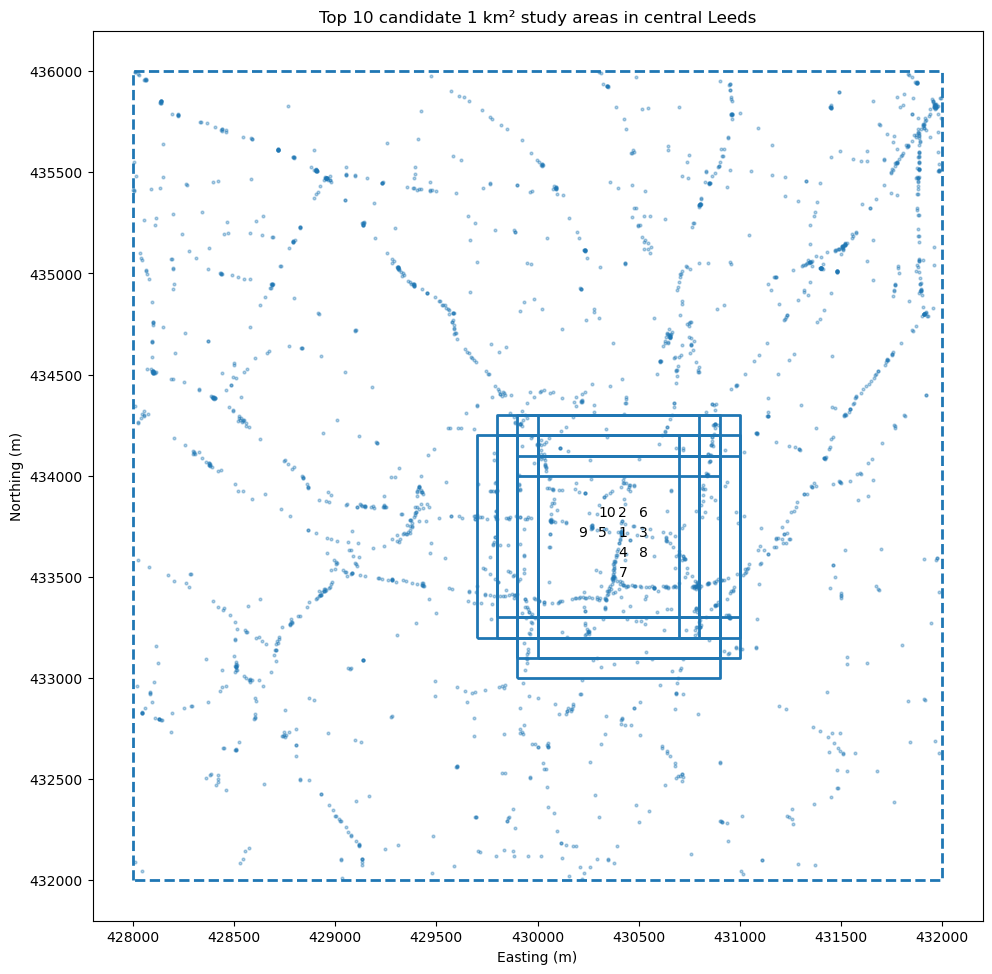

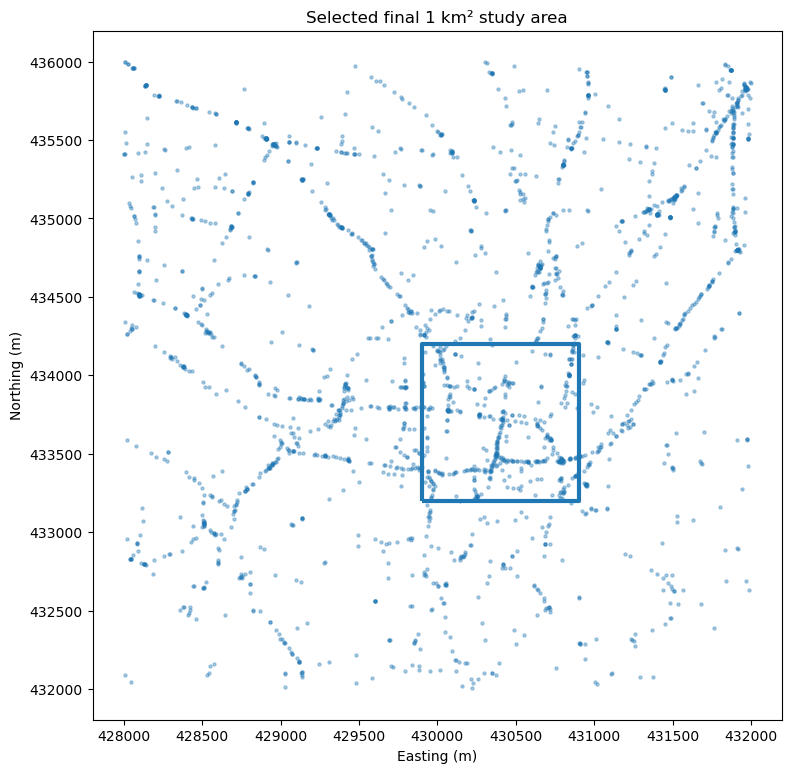


已輸出：
- candidate_windows_ranked.csv
- final_study_area_summary.csv
Run Task A

=== Task A summary ===
area_km2: 1.0
total_nodes: 211
total_edges: 359
total_intersections: 179
total_edge_length_m: 21833.70550916389
total_edge_length_km: 21.83370550916389
spatial_diameter_m: 2930.0062878198755
avg_street_length_m: 60.81812119544259
node_density_per_km2: 211.0
intersection_density_per_km2: 179.0
edge_density_m_per_km2: 21833.70550916389
average_circuitry: 1.607120065192688
planarity_info: {'topologically_planar': False, 'n_nodes_undirected': 211, 'n_edges_undirected': 295}


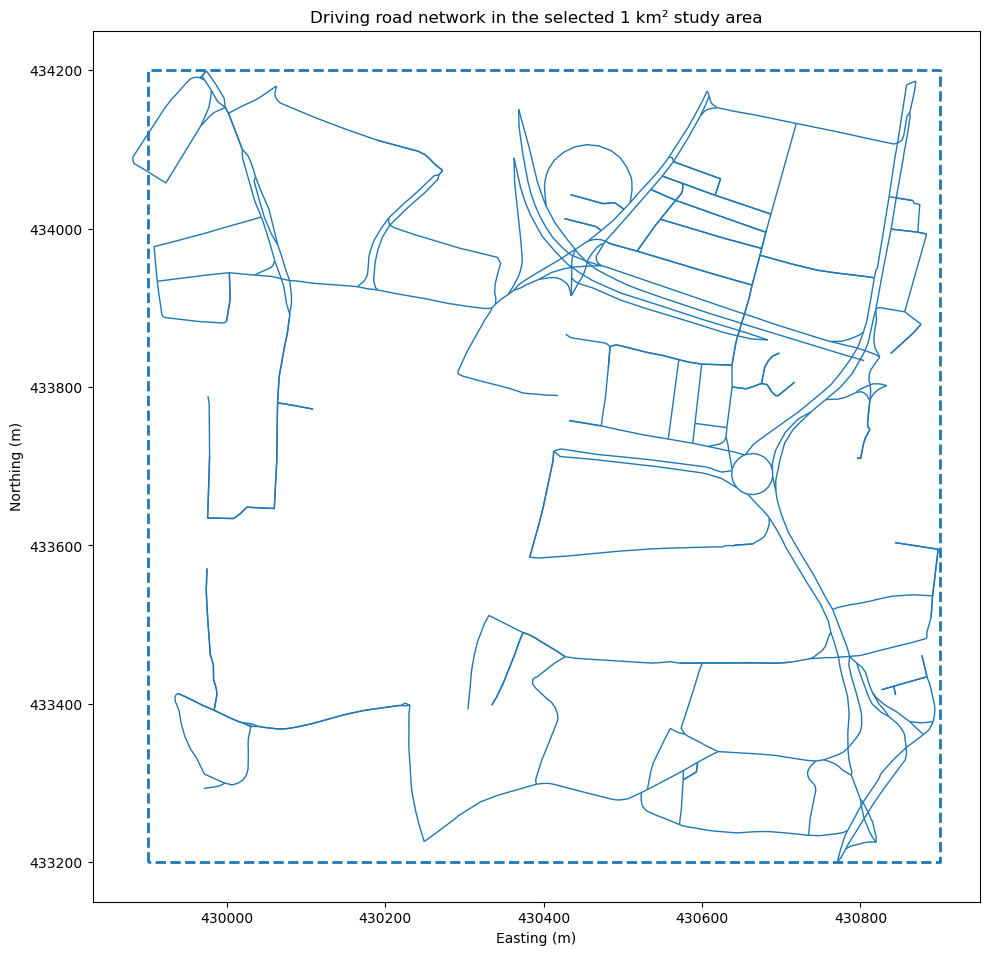

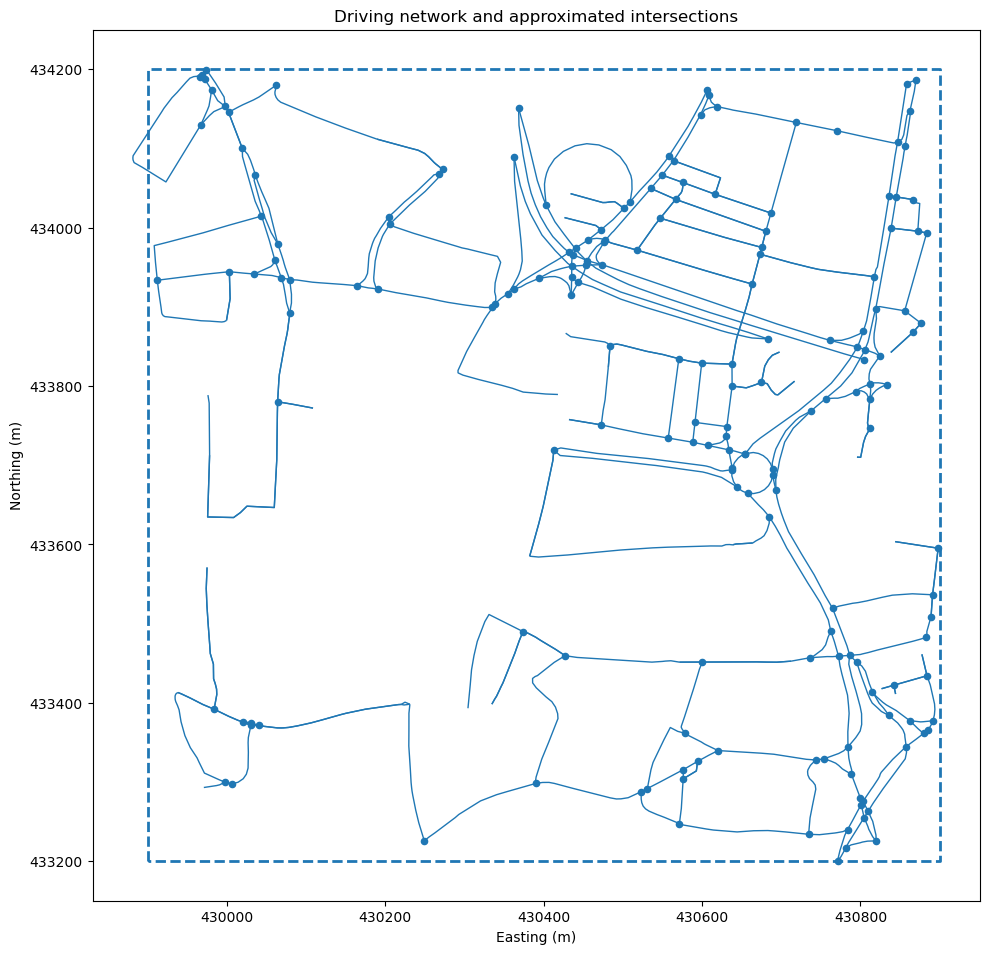


已輸出：
- taskA_summary_metrics.csv
- taskA_summary_table.csv


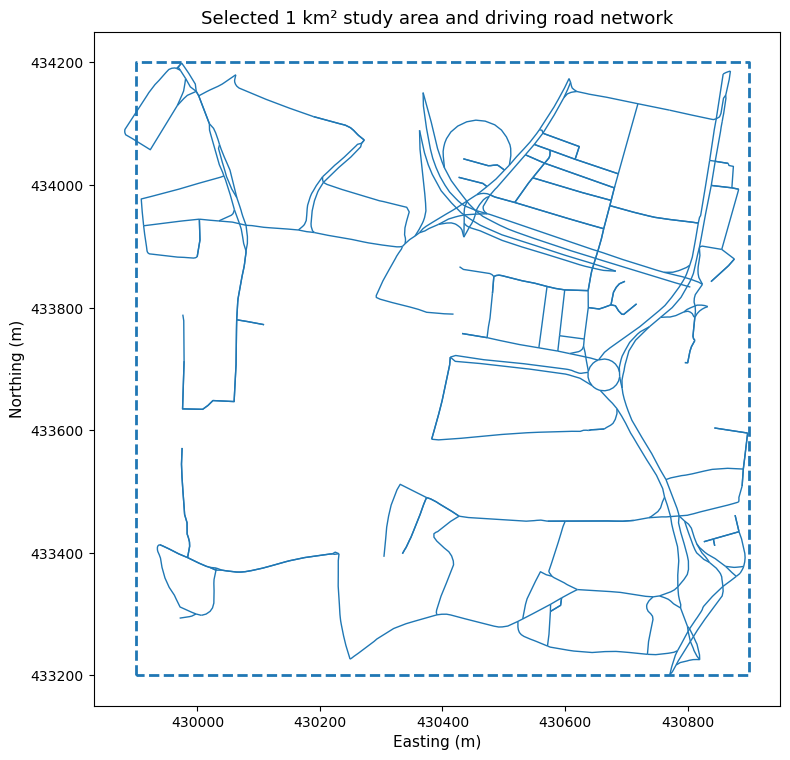

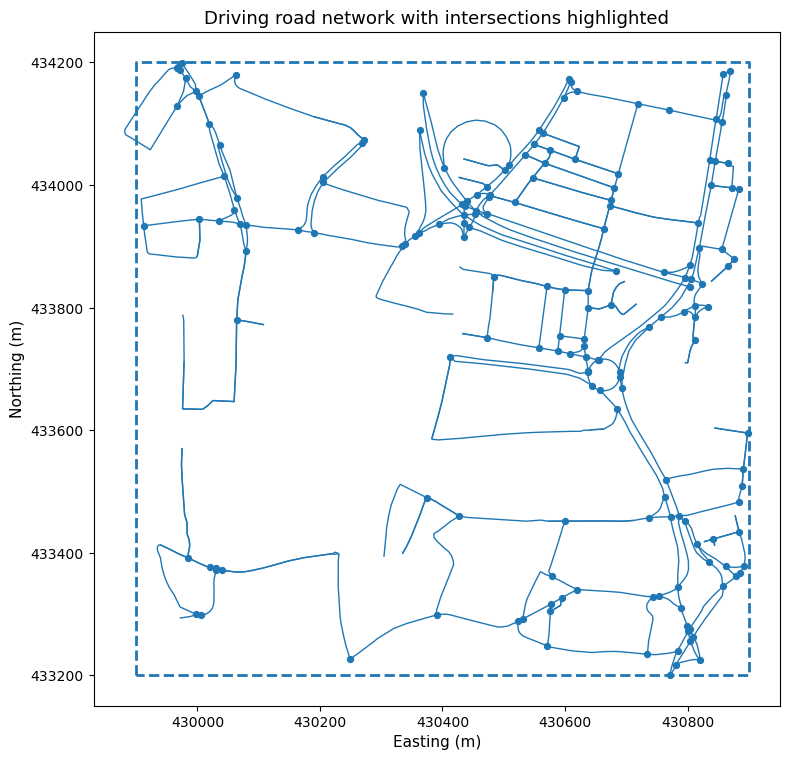

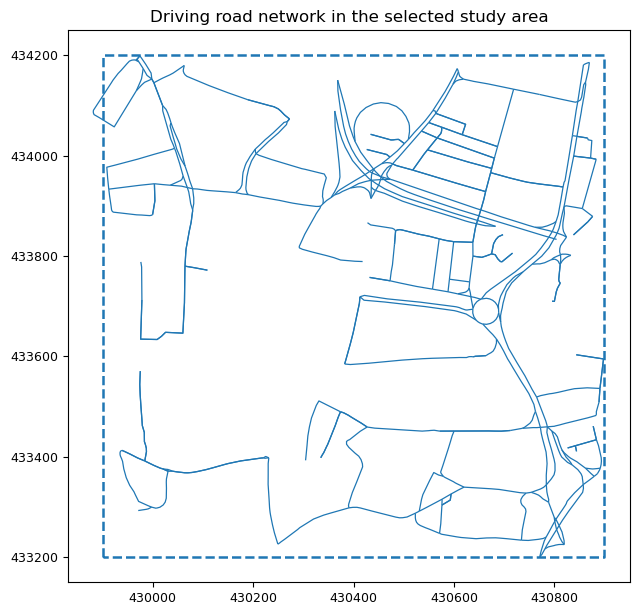

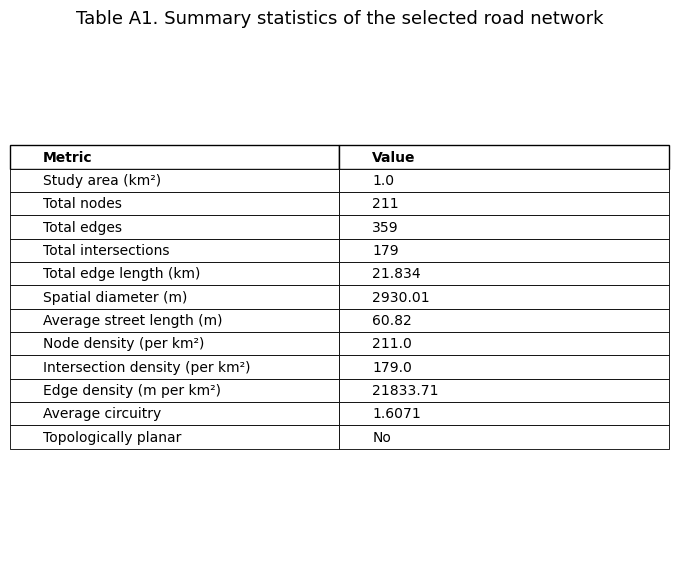


Formal Task A outputs saved:
- taskA_outputs\taskA_road_network.png
- taskA_outputs\taskA_intersections.png
- taskA_outputs\taskA_road_network_compact.png
- taskA_outputs\taskA_summary_table_report.csv
- taskA_outputs\taskA_summary_table.png


C:\Users\qwasz\miniconda3\envs\network_analysis\lib\site-packages\spaghetti\network.py:3412: FutureWarning: Objects based on the `Geometry` class will deprecated and removed in a future version of libpysal.
  pts = [cg.shapes.Point((p.x, p.y)) for p in pts_objs]
C:\Users\qwasz\miniconda3\envs\network_analysis\lib\site-packages\spaghetti\util.py:572: FutureWarning: Objects based on the `Geometry` class will deprecated and removed in a future version of libpysal.
  return cg.Chain([cg.Point(_vcoords[v]) for v in _vs] if _vcoords else _vs)
C:\Users\qwasz\miniconda3\envs\network_analysis\lib\site-packages\libpysal\cg\shapes.py:1025: FutureWarning: Objects based on the `Geometry` class will deprecated and removed in a future version of libpysal.
  self._bounding_box = Rectangle(


pp_name = accidents
keys sample = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
has key 0?  True
has key '0'?  False
npoints = 452


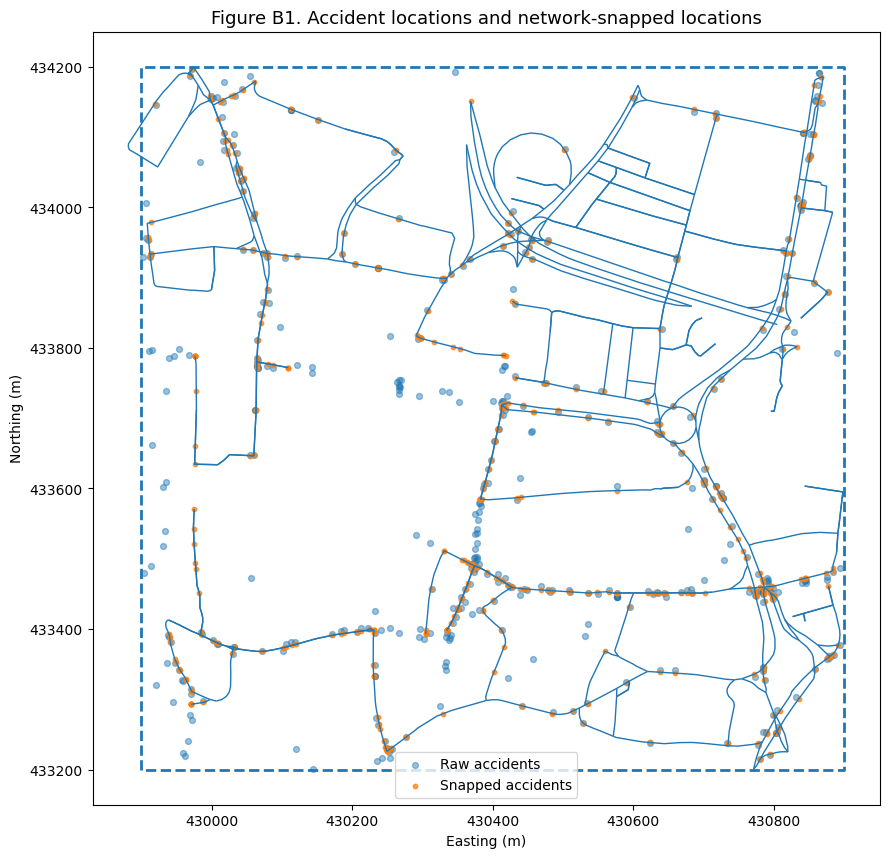

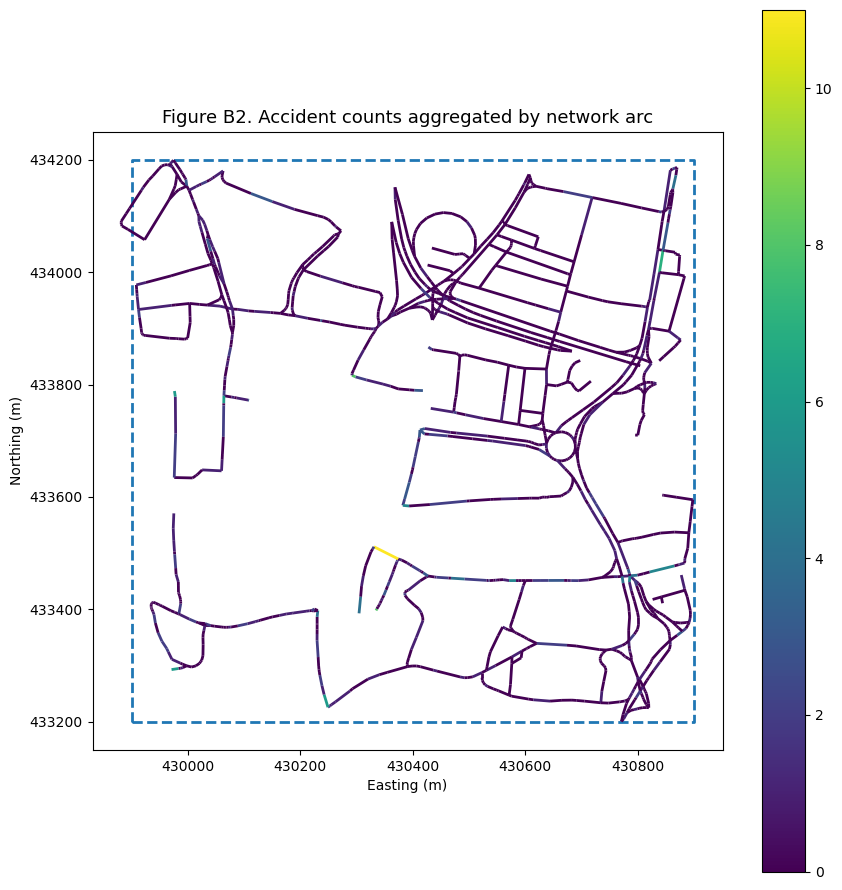

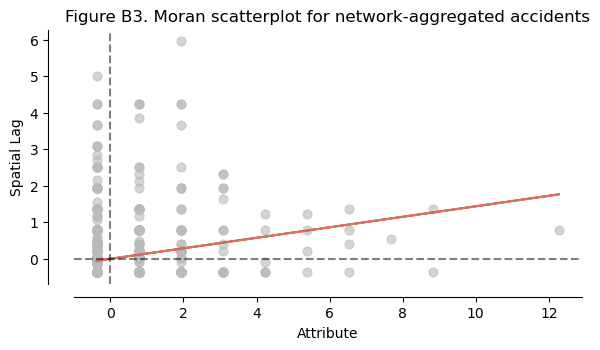

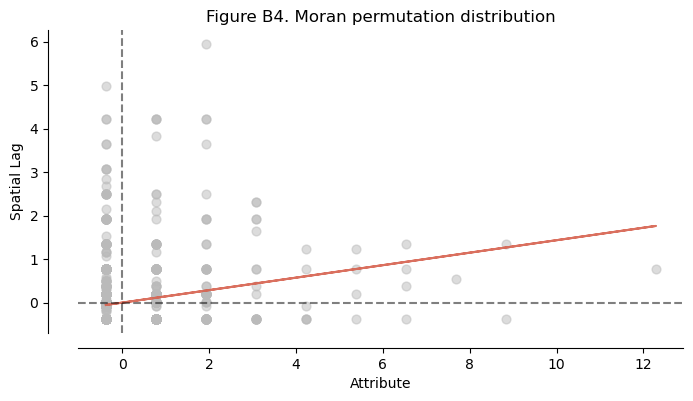

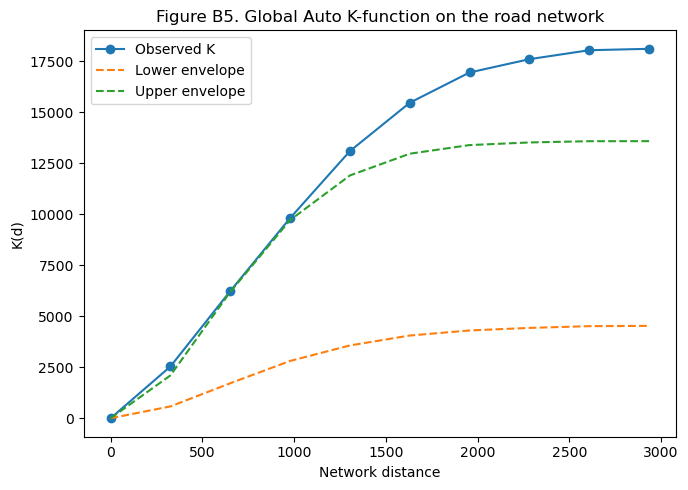

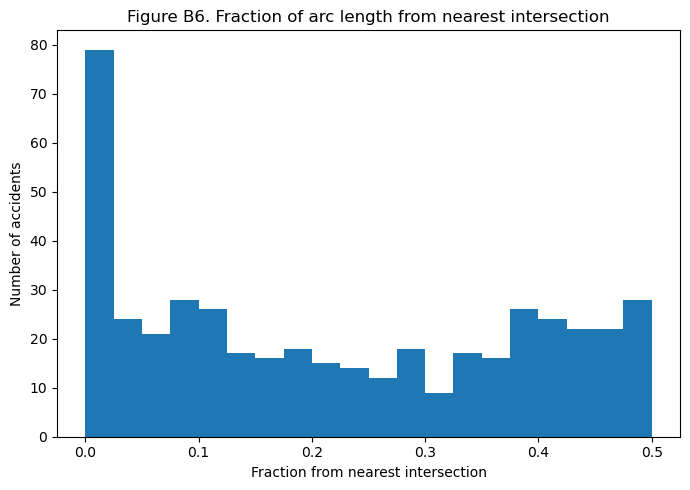

C:\Users\qwasz\miniconda3\envs\network_analysis\lib\site-packages\pyogrio\geopandas.py:662: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(
C:\Users\qwasz\miniconda3\envs\network_analysis\lib\site-packages\pyogrio\geopandas.py:662: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(
C:\Users\qwasz\miniconda3\envs\network_analysis\lib\site-packages\pyogrio\geopandas.py:662: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(



=== Task B (spaghetti) summary ===
Accidents in study area: 452
Moran's I: 0.1437
p_sim: 0.0010

Intersection proximity summary:
 n_accidents  mean_fraction_from_nearest_intersection  median_fraction_from_nearest_intersection      q25      q75  share_within_10pct_of_arc_from_intersection  share_within_20pct_of_arc_from_intersection  share_beyond_40pct_of_arc_from_intersection
         452                                 0.218213                                    0.19484 0.054903 0.380888                                     0.336283                                     0.506637                                     0.212389

Saved outputs:
part2_taskB_spaghetti_outputs\part2_taskB_accident_distribution.png
part2_taskB_spaghetti_outputs\part2_taskB_edge_accidents.png
part2_taskB_spaghetti_outputs\part2_taskB_moransI_scatter.png
part2_taskB_spaghetti_outputs\part2_taskB_moransI_distribution.png
part2_taskB_spaghetti_outputs\part2_taskB_network_k_function.png
part2_taskB_spaghetti_outputs\p

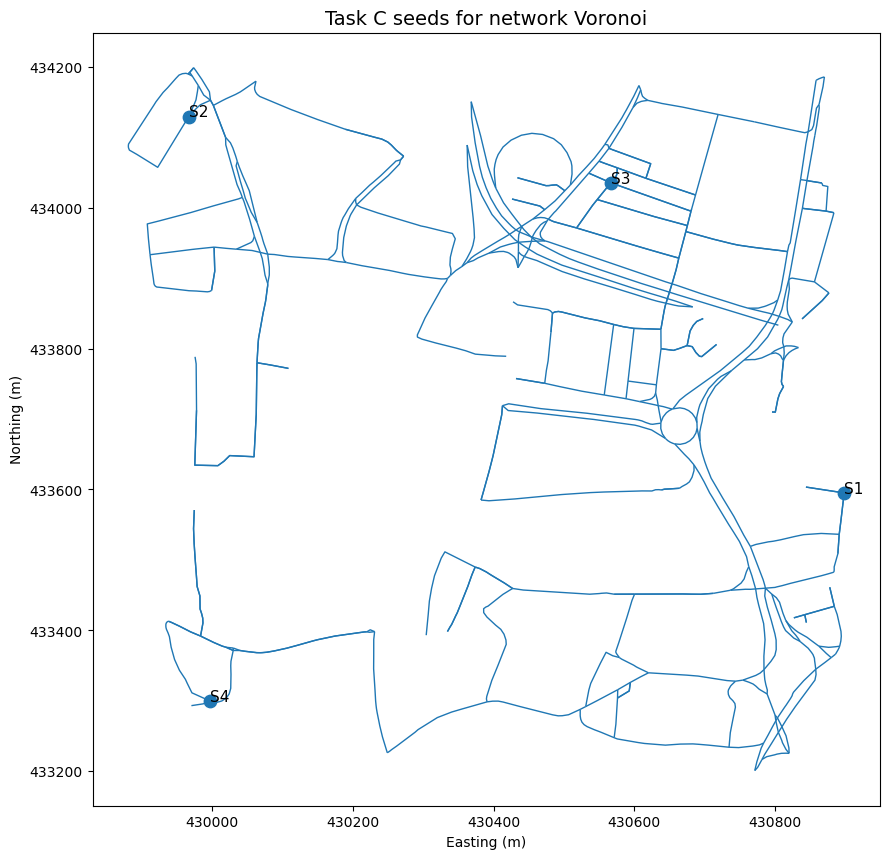

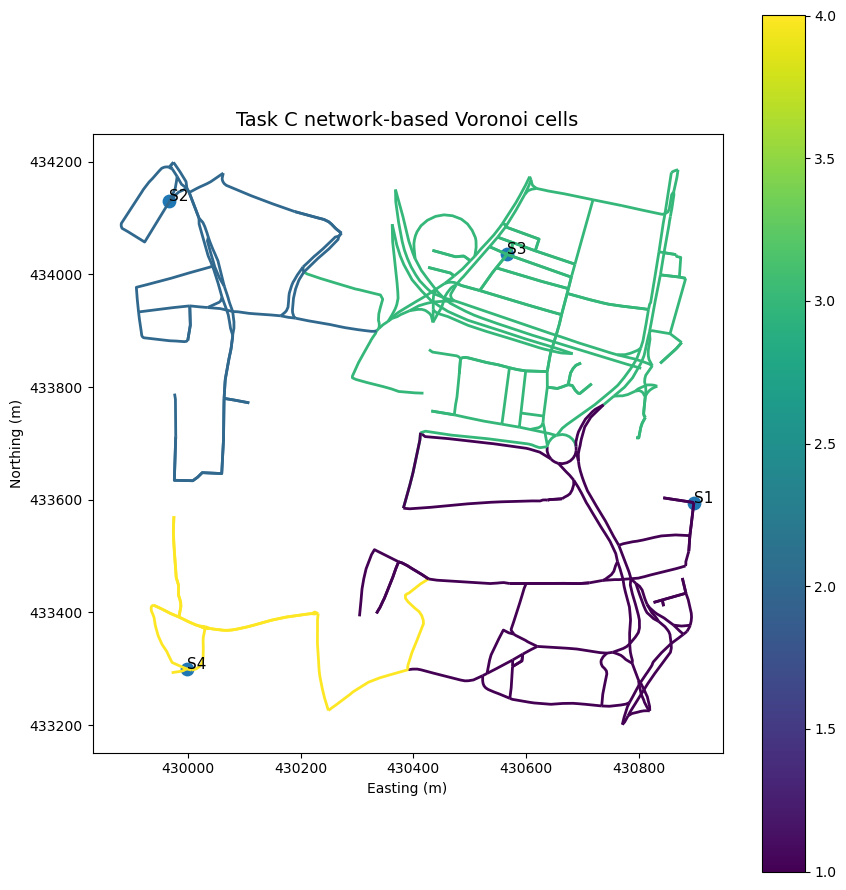

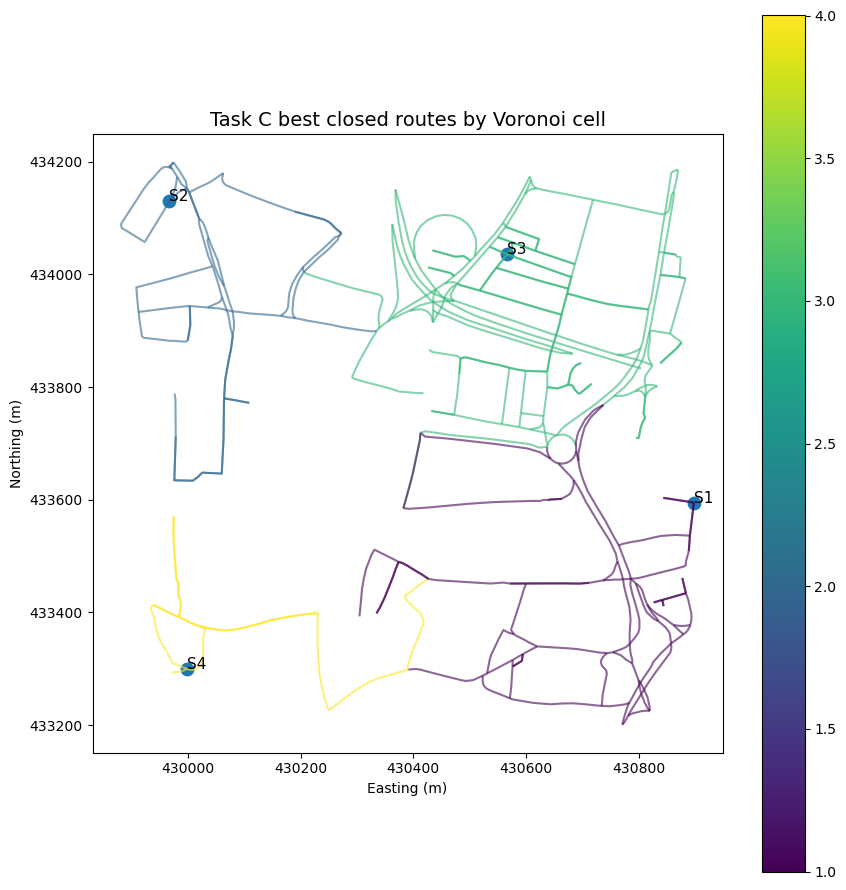

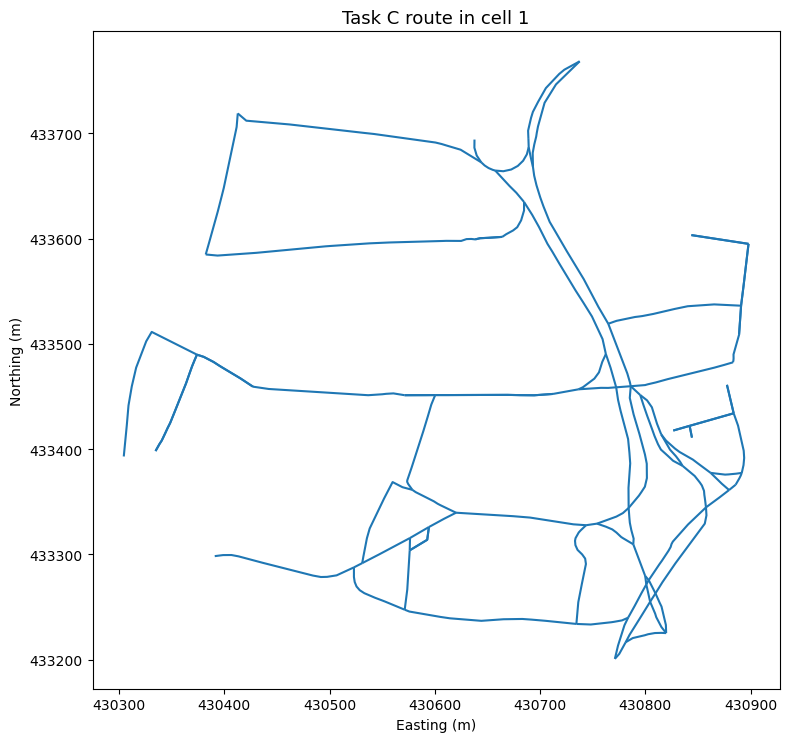

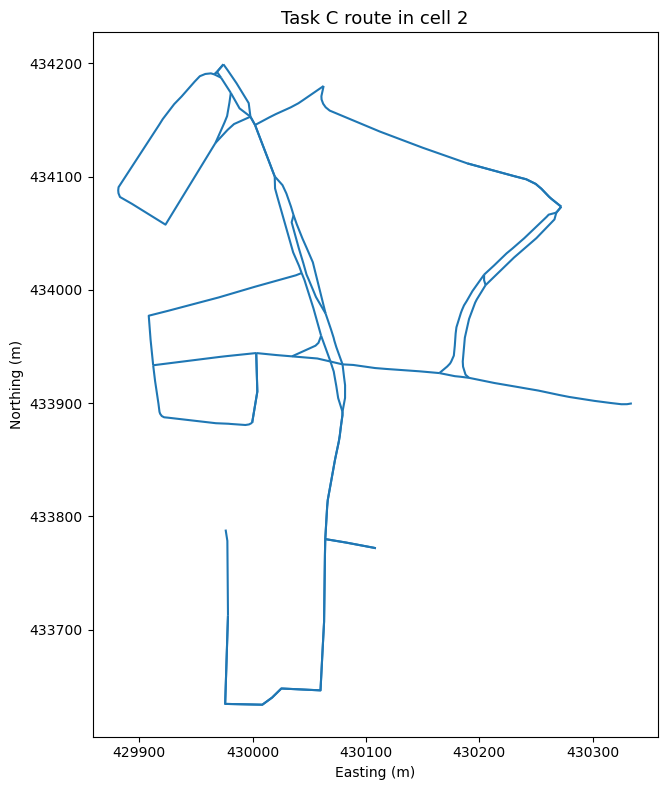

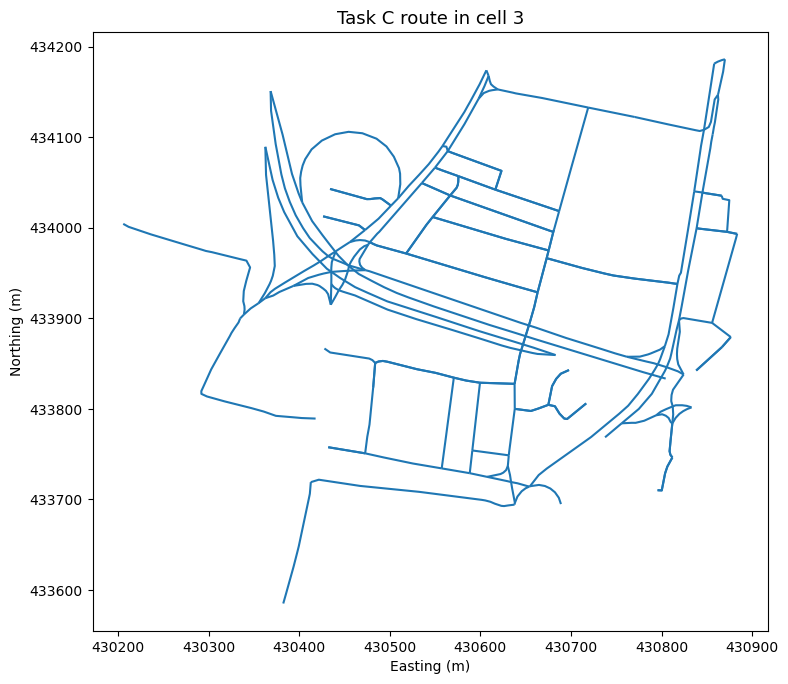

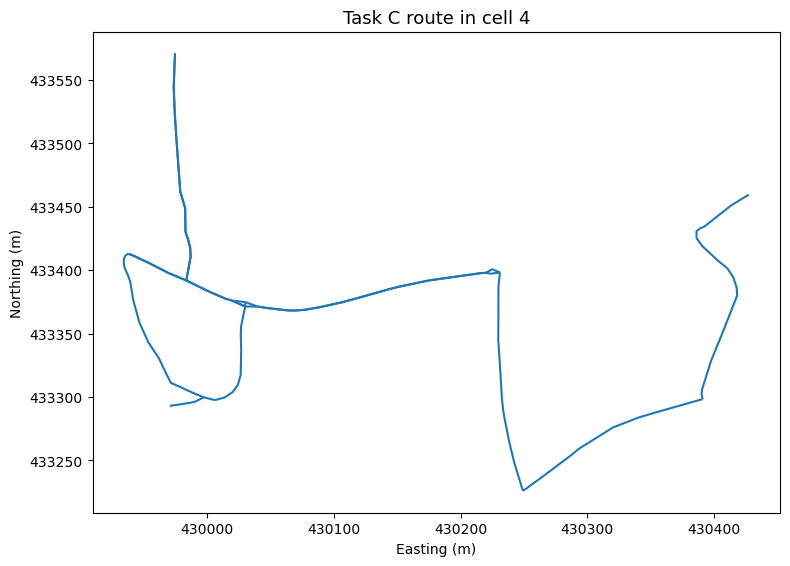

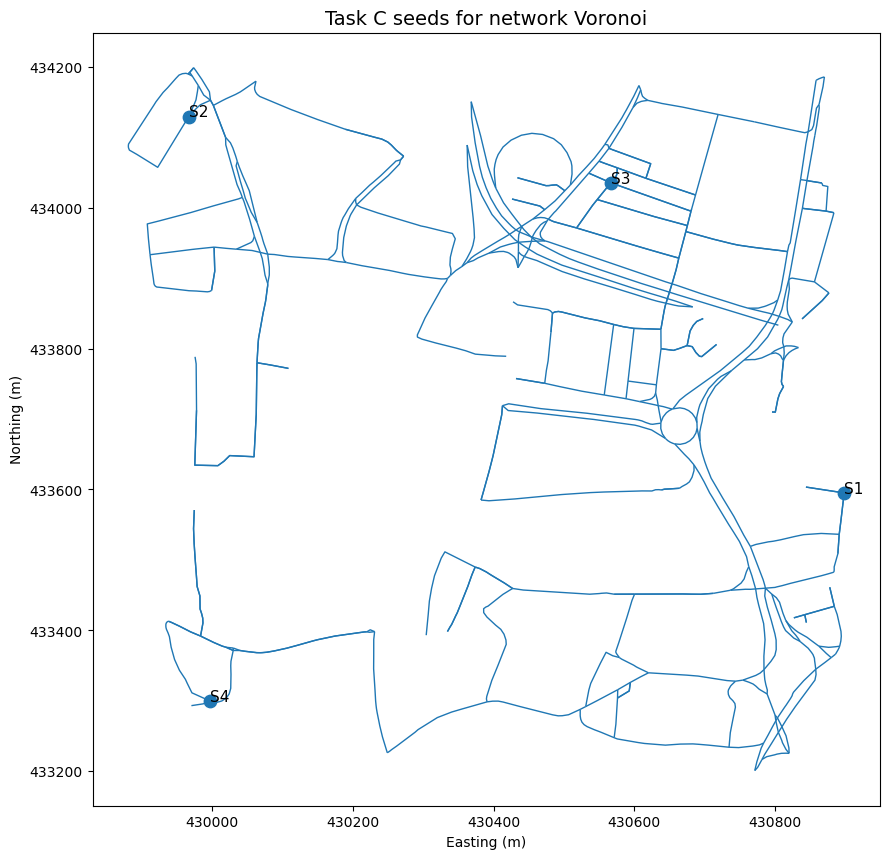

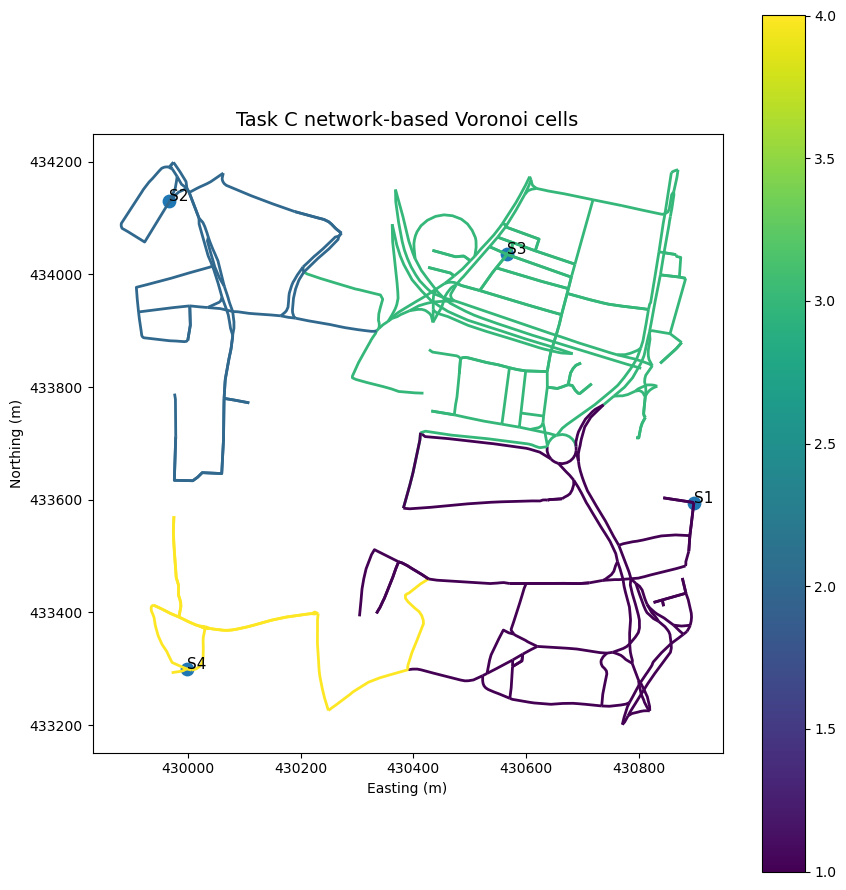

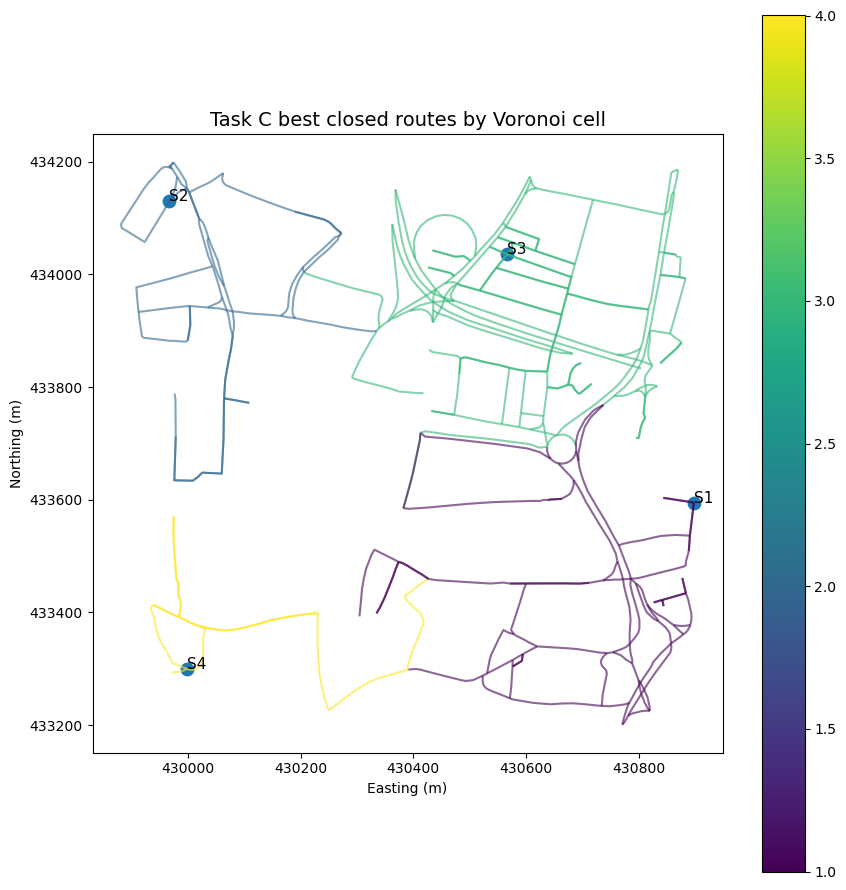

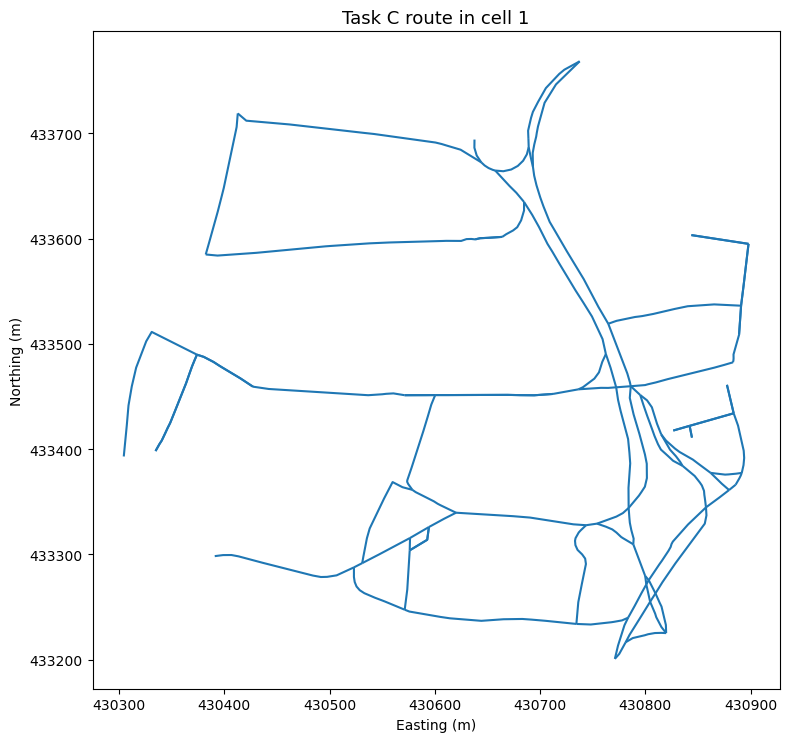

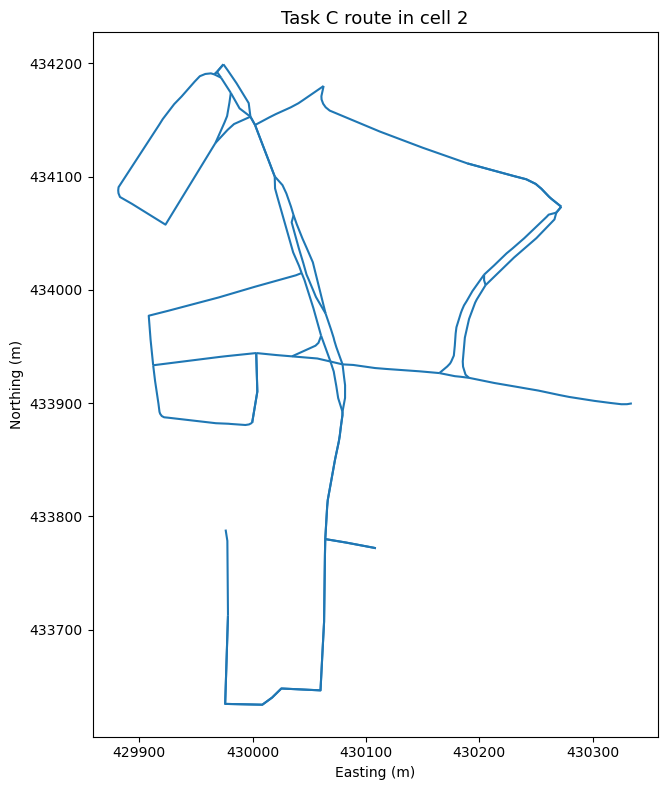

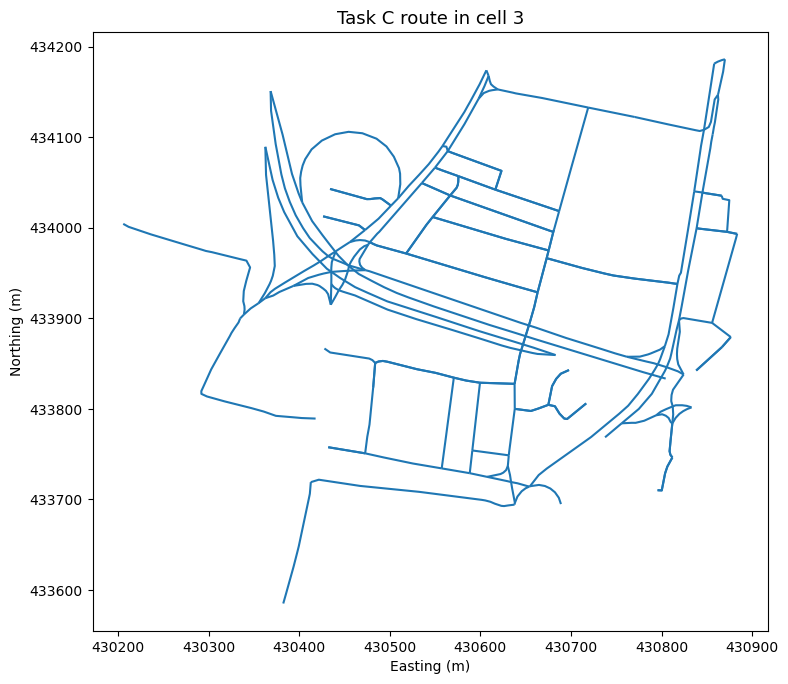

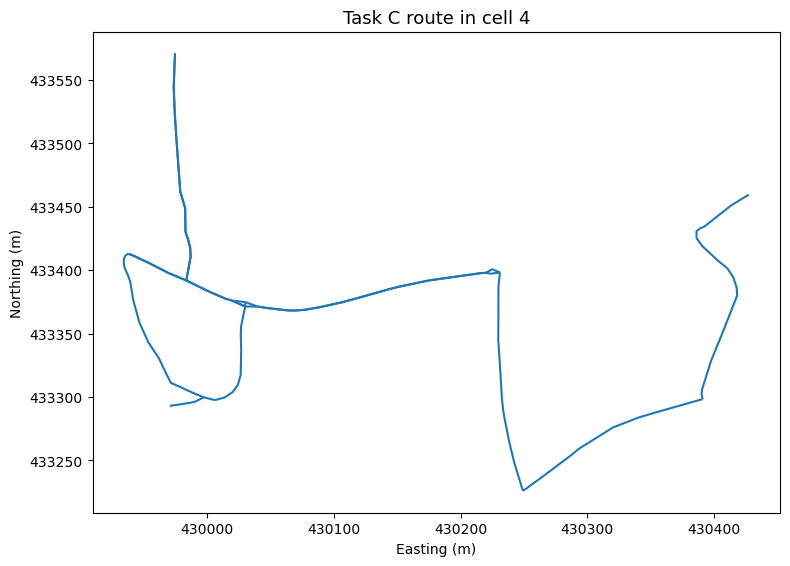


=== Task C summary ===

Initial cell summary:
 cell_id  n_nodes  n_edges  total_edge_length_m  total_edge_length_km  is_connected  n_components  route_length_km  abs_error_km  success_within_tolerance
       1       62       83          5207.684884              5.207685             1             1              NaN           NaN                         0
       2       32       43          3673.192039              3.673192             1             1              NaN           NaN                         0
       3      103      142         10080.504231             10.080504             1             1              NaN           NaN                         0
       4       14       16          1581.658589              1.581659             1             1              NaN           NaN                         0

Redesign cell summary:
 cell_id  n_nodes  n_edges  total_edge_length_m  total_edge_length_km  is_connected  n_components  route_length_km  abs_error_km  success_within_tolerance

In [20]:
if __name__ == '__main__':
    results = process_data()

    # -------------------------
    #  Run Task A
    # -------------------------
    print("Run Task A")
    taskA = run_task_a(results)
    taskA_formal = export_taskA_formal_outputs(taskA)

    # # -------------------------
    # # Run Task B
    # # -------------------------
    # print("Run Task B")
    # taskB = run_taskB(results, taskA)

    # -------------------------
    # Run Task B (spaghetti)
    # -------------------------
    taskB_spaghetti = run_taskB_spaghetti(results, taskA)

    # --------------------------------------------------
    # 11. Run Task C
    # --------------------------------------------------
    print("Run Task C")
    taskC = run_taskC(
        results=results,
        taskA=taskA,
        taskB_spaghetti=taskB_spaghetti,
        target_km=42.0,
        route_tolerance_km=1.0,
        route_trials=3000,
        high_risk_quantile=0.90
    )

    print("-------------done----------------")